# Firasa - EDA Notebook 01
## Exploratory Data Analysis: Primary Behavioral Dataset



This notebook performs a complete exploratory analysis of the primary training
dataset (`behavioral_analytics.csv`, 1,200 students × 36 features) that drives
the clustering and academic-risk classification layers of Firasa. The goal is
to understand the structure, distributions, relationships, and data-quality
characteristics of the behavioral, psychological, academic, and career features
before any modelling decision is made. Every constant is sourced from
`ml/config.py` .

## 1. Setup and configuration

Load the shared configuration and the validated primary dataset through the
project data loader, configure plotting, and define the helper functions used
throughout. The derived `procrastination_level` feature (engineered from
`internal_barrier`, `study_consistency`, and `tasks_on_time`, per the rules in
`config.py`) is computed here so it is available to every subsequent analysis.

In [1]:
import logging
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


def _find_project_root(start: Path) -> Path:
    """Locate the project root by walking up until ml/config.py is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "ml" / "config.py").exists():
            return candidate
    raise RuntimeError(f"Could not locate the project root from {start}")


PROJECT_ROOT = _find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ml import config
from data.data_loader import load_dataset

logging.basicConfig(
    level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s"
)
logger = logging.getLogger("eda_behavioral")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
np.random.seed(config.RANDOM_SEED)

TARGET = config.DS1_TARGET
NATIVE_NUMERIC = config.DS1_NUMERIC_FEATURES
ORDINAL_FEATURES = list(config.DS1_ORDINAL_FEATURES)
NOMINAL_FEATURES = config.DS1_NOMINAL_FEATURES


def save_plot(fig, filename: str) -> None:
    """Persist a figure to the plots directory, then display and close it."""
    output_path = config.PLOTS_DIR / filename
    fig.savefig(output_path, dpi=120, bbox_inches="tight")
    logger.info("Saved plot -> %s", output_path.name)
    plt.show()
    plt.close(fig)


def derive_procrastination_level(frame: pd.DataFrame) -> pd.Series:
    """Engineer the ordinal procrastination_level proxy from config rules."""
    score = pd.Series(0.0, index=frame.index)
    for column, mapping in config.PROCRASTINATION_COMPONENT_SCORES.items():
        score = score + frame[column].map(mapping).fillna(0)
    return pd.cut(
        score,
        bins=config.PROCRASTINATION_SCORE_BINS,
        labels=config.PROCRASTINATION_LEVELS,
    )


def build_numeric_frame(frame: pd.DataFrame) -> pd.DataFrame:
    """Return a fully numeric view: native numerics + ordinal-encoded codes."""
    numeric = frame[NATIVE_NUMERIC].copy()
    for column, order in config.DS1_ORDINAL_FEATURES.items():
        code_map = {category: rank for rank, category in enumerate(order)}
        numeric[column] = frame[column].map(code_map)
    proc_map = {level: rank for rank, level in enumerate(config.PROCRASTINATION_LEVELS)}
    proc_codes = derive_procrastination_level(frame).astype(object).map(proc_map)
    numeric[config.PROCRASTINATION_FEATURE] = pd.to_numeric(proc_codes)
    return numeric


df = load_dataset("behavioral_analytics")
df[config.PROCRASTINATION_FEATURE] = derive_procrastination_level(df)
numeric_df = build_numeric_frame(df)
risk_code = df[TARGET].map(config.RISK_LABEL_MAP)

logger.info("Primary dataset loaded for EDA: %d rows x %d columns", *df.shape)
logger.info(
    "Derived procrastination_level distribution: %s",
    df[config.PROCRASTINATION_FEATURE].value_counts().to_dict(),
)

2026-06-22 22:54:09,520 | INFO | Loaded behavioral_analytics: 1200 rows x 36 columns from behavioral_analytics.csv


2026-06-22 22:54:09,521 | INFO | behavioral_analytics passed schema validation.


2026-06-22 22:54:09,531 | INFO | Primary dataset loaded for EDA: 1200 rows x 37 columns


2026-06-22 22:54:09,532 | INFO | Derived procrastination_level distribution: {'Medium': 566, 'High': 499, 'Low': 135}


## 2. Dataset Overview and initial analysis (EDA Step 1)

A structured exploration of the raw dataset: shape, per-column data type, null counts
and percentages, duplicate-row count, and descriptive statistics for the
native numeric features. This establishes the data-quality baseline that
informs the imputation and encoding decisions we make ahead in preprocessing.

In [2]:
logger.info("Shape: %d rows x %d columns", *df.shape)
logger.info("Duplicate rows: %d", int(df.duplicated().sum()))

audit = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "nulls": df.isnull().sum(),
        "null_pct": (df.isnull().mean() * 100).round(2),
        "n_unique": df.nunique(),
    }
)
audit.index.name = "feature"
audit

2026-06-22 22:54:09,537 | INFO | Shape: 1200 rows x 37 columns


2026-06-22 22:54:09,540 | INFO | Duplicate rows: 0


,dtype,nulls,null_pct,n_unique
feature,,,,
student_id,object,0,0.00,1200
timestamp,object,0,0.00,1171
year_class,object,0,0.00,6
program_stream,object,0,0.00,7
age,int64,0,0.00,10
gender,object,0,0.00,3
cgpa_category,object,0,0.00,4
academic_satisfaction,object,0,0.00,5
study_hours_daily,object,0,0.00,3


In [3]:
df[NATIVE_NUMERIC].describe().round(2)

feature,age,daily_productivity,energy_level,stress_level,routine_rating
count,1200.00,1166.00,1172.00,1165.00,1159.00
mean,20.81,2.69,3.23,3.15,2.11
std,2.19,1.18,1.15,1.19,0.79
min,17.00,1.00,1.00,1.00,1.00
25%,19.00,2.00,2.00,2.00,1.00
50%,21.00,3.00,3.00,3.00,2.00
75%,22.00,3.00,4.00,4.00,3.00
max,26.00,5.00,5.00,5.00,3.00


### Feature dictionary

| Feature | Type | Values / range | Measures |
|---|---|---|---|
| student_id | identifier | 1,200 unique | Anonymous student key (dropped) |
| timestamp | identifier | datetime string | Submission time (dropped) |
| year_class | nominal | 6 levels (FY–Final, PG) | Academic year / cohort |
| program_stream | nominal | 7 (BCA, BCom, BSc IT, …) | Degree programme |
| age | numeric | 18–27 | Student age in years |
| gender | excluded | 3 | Protected attribute (EDA only) |
| cgpa_category | ordinal | 4 bins (5.0–6.9 → 9.5–10.0) | Current CGPA band |
| academic_satisfaction | ordinal | 5 (Very unsatisfied → Very satisfied) | Satisfaction with progress |
| study_hours_daily | ordinal | 3 (<1h → >2h) | Daily self-study time |
| daily_productivity | numeric | 1–5 scale | Self-rated productivity |
| revision_frequency | ordinal | 4 (Never → Daily) | How often material is revised |
| focus_duration | ordinal | 3 (30–60m → >2h) | Sustained focus window |
| screen_time_non_study | ordinal | 3 (2–4h → >6h) | Non-study screen time |
| main_distractor | nominal | 5 | Primary distraction source |
| study_consistency | ordinal | 3 (Rarely → Mostly consistent) | Consistency of study routine |
| tasks_on_time | ordinal | 4 (Rarely → Always) | Task punctuality |
| preparation_status | ordinal | 3 (Thinking → Actively preparing) | Goal preparation stage |
| career_goal_clarity | ordinal | 3 (Not clear → Very clear) | Clarity of career direction |
| skills_developing | nominal | 3 (Hard / Soft / Both) | Skill focus |
| energy_level | numeric | 1–5 scale | Self-rated daily energy |
| stress_level | numeric | 1–5 scale | Self-rated stress |
| routine_rating | numeric | 1–5 scale | Quality of daily routine |
| sleepy_during_study | ordinal | 4 (Never → Always) | Drowsiness while studying |
| sleep_hours | ordinal | 3 (4–5h → >8h) | Typical sleep duration |
| career_interest | nominal | 7 (AI/ML, Cyber, …) | Target career domain |
| online_courses | ordinal | 4 (Not interested → Enrolled) | Online learning engagement |
| projects_internships | ordinal | 3 (None → Actively working) | Practical experience |
| programming_foundation | ordinal | 3 (Limited → Strong) | Coding proficiency |
| events_participation | ordinal | 3 (Never → Occasionally) | Event / hackathon engagement |
| assignments_on_time | ordinal | 4 (Rarely → Always) | Assignment punctuality |
| attendance_percentage | ordinal | 5 (<50% → >85%) | Class attendance band |
| strongest_asset | nominal | 4 | Self-identified strength |
| internal_barrier | nominal | 4 | Primary internal obstacle |
| external_resources | ordinal | 3 (Never → Occasionally) | Use of external help |
| external_pressure | ordinal | 4 (No → High impact) | Family / external pressure |
| performance_risk_level | target | 3 (Low / Moderate / High) | Academic risk label |

## 3. Univariate analysis (EDA Step 2)

Distribution of every feature in isolation i.e. without bringing anotheer feature as a combination.The numeric features use a
histogram with a kernel-density overlay; categorical features (ordinal and
nominal) use a frequency plot annotated with class percentages. Ordinal
features are plotted in their meaningful low→high order. 

2026-06-22 22:54:09,729 | INFO | Saved plot -> EDA_01_univariate_age.png


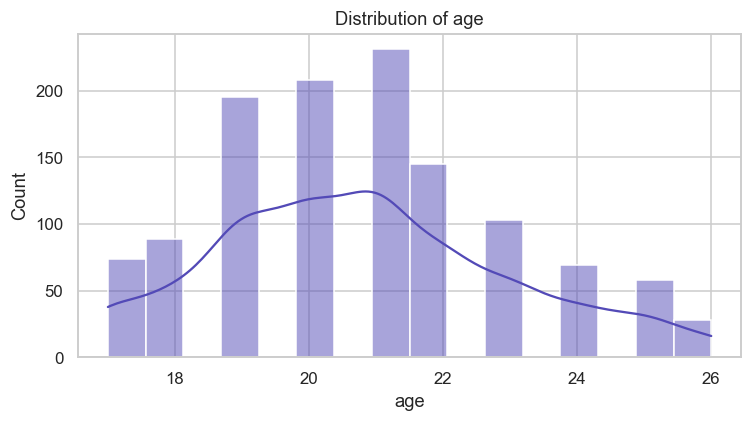

2026-06-22 22:54:09,903 | INFO | Saved plot -> EDA_01_univariate_daily_productivity.png


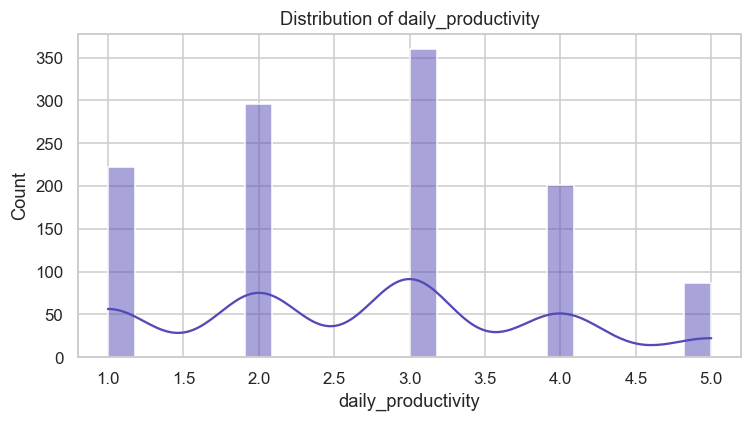

2026-06-22 22:54:10,066 | INFO | Saved plot -> EDA_01_univariate_energy_level.png


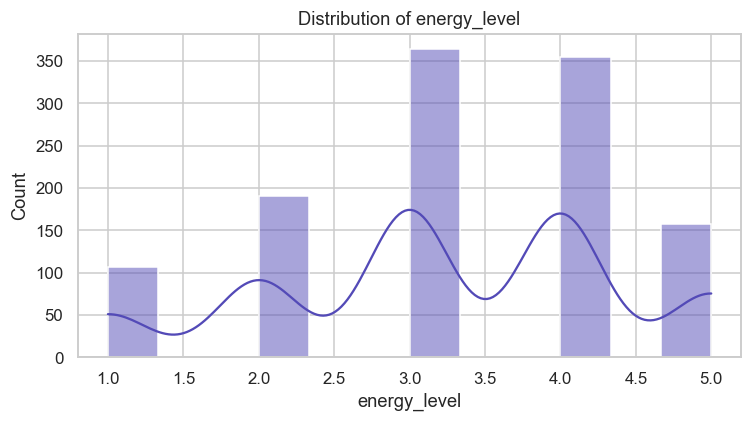

2026-06-22 22:54:10,229 | INFO | Saved plot -> EDA_01_univariate_stress_level.png


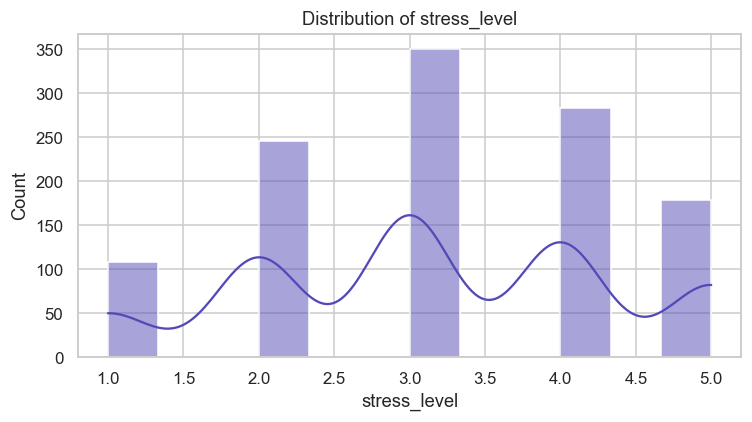

2026-06-22 22:54:10,390 | INFO | Saved plot -> EDA_01_univariate_routine_rating.png


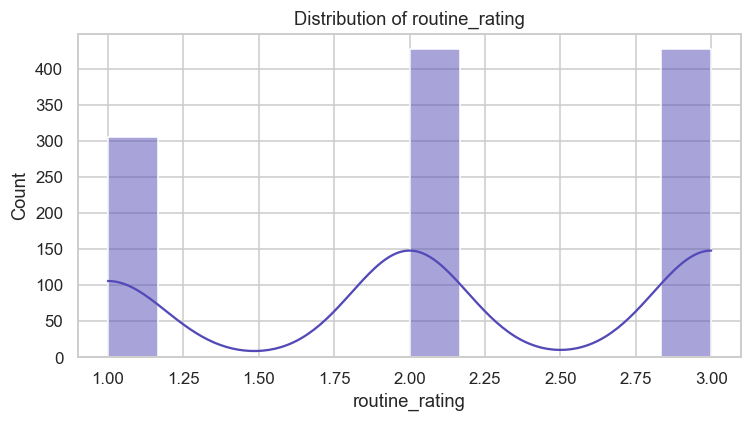

In [4]:
def plot_numeric_distribution(column: str) -> None:
    """Histogram with KDE for a numeric feature."""
    fig, ax = plt.subplots(figsize=(7, 4))
    sns.histplot(data=df, x=column, kde=True, color=config.BRAND_PRIMARY, ax=ax)
    ax.set_title(f"Distribution of {column}")
    plt.tight_layout()
    save_plot(fig, f"EDA_01_univariate_{column}.png")


def plot_categorical_distribution(column: str, order=None) -> None:
    """Percentage-annotated frequency plot for a categorical feature."""
    series = df[column]
    if order is None:
        order = series.value_counts().index.tolist()
    counts = series.value_counts().reindex(order).fillna(0)
    total = series.notna().sum()
    horizontal = max(len(str(level)) for level in order) > 18
    labels = [str(level) for level in order]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    if horizontal:
        sns.barplot(x=counts.values, y=labels, color=config.BRAND_PRIMARY, ax=ax)
        for i, value in enumerate(counts.values):
            ax.text(value, i, f" {value / total * 100:.1f}%", va="center", fontsize=8)
        ax.set_xlabel("Count")
        ax.set_ylabel(column)
    else:
        sns.barplot(x=labels, y=counts.values, color=config.BRAND_PRIMARY, ax=ax)
        for i, value in enumerate(counts.values):
            ax.text(i, value, f"{value / total * 100:.1f}%", ha="center", va="bottom", fontsize=8)
        ax.set_xlabel(column)
        ax.set_ylabel("Count")
        plt.xticks(rotation=30, ha="right")
    ax.set_title(f"Distribution of {column}")
    plt.tight_layout()
    save_plot(fig, f"EDA_01_univariate_{column}.png")


for column in NATIVE_NUMERIC:
    plot_numeric_distribution(column)

2026-06-22 22:54:10,533 | INFO | Saved plot -> EDA_01_univariate_cgpa_category.png


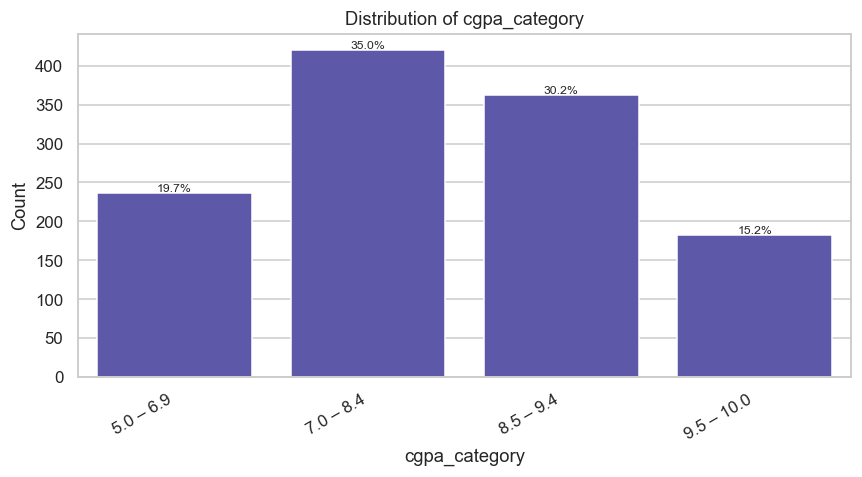

2026-06-22 22:54:10,656 | INFO | Saved plot -> EDA_01_univariate_attendance_percentage.png


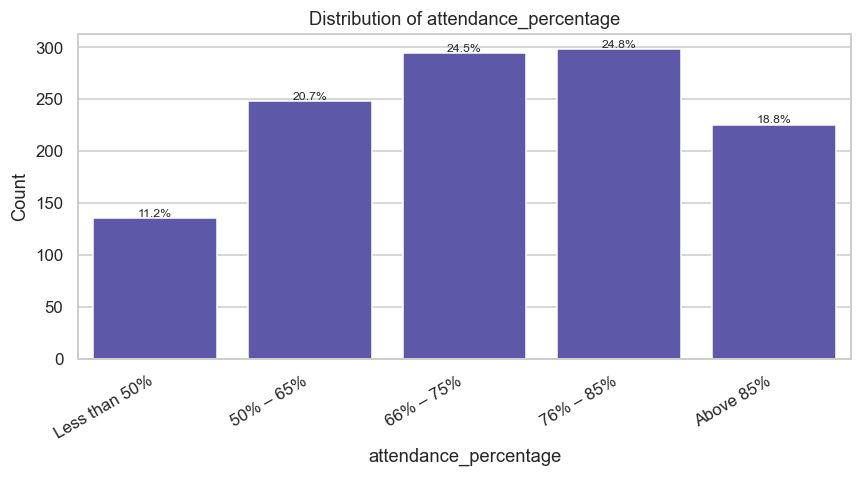

2026-06-22 22:54:10,783 | INFO | Saved plot -> EDA_01_univariate_academic_satisfaction.png


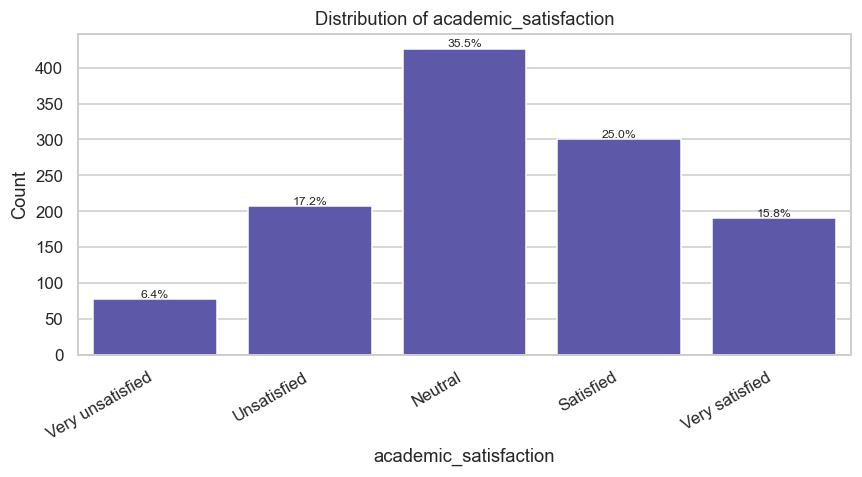

2026-06-22 22:54:10,897 | INFO | Saved plot -> EDA_01_univariate_study_hours_daily.png


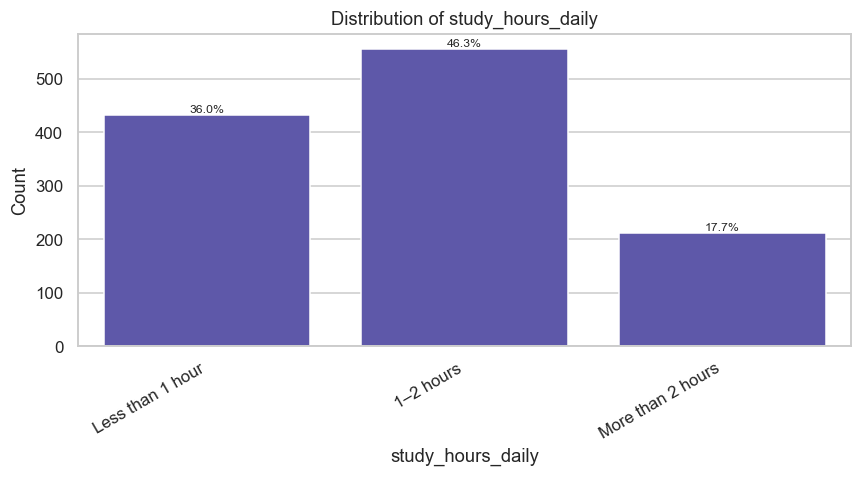

2026-06-22 22:54:11,004 | INFO | Saved plot -> EDA_01_univariate_revision_frequency.png


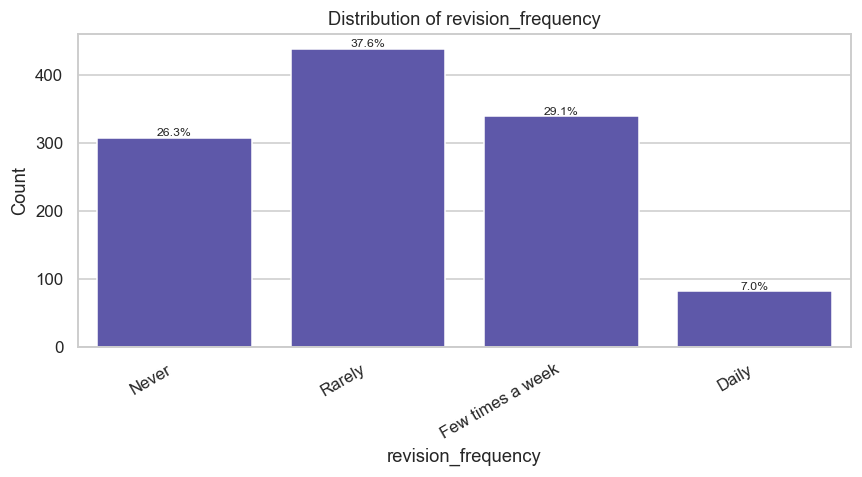

2026-06-22 22:54:11,106 | INFO | Saved plot -> EDA_01_univariate_focus_duration.png


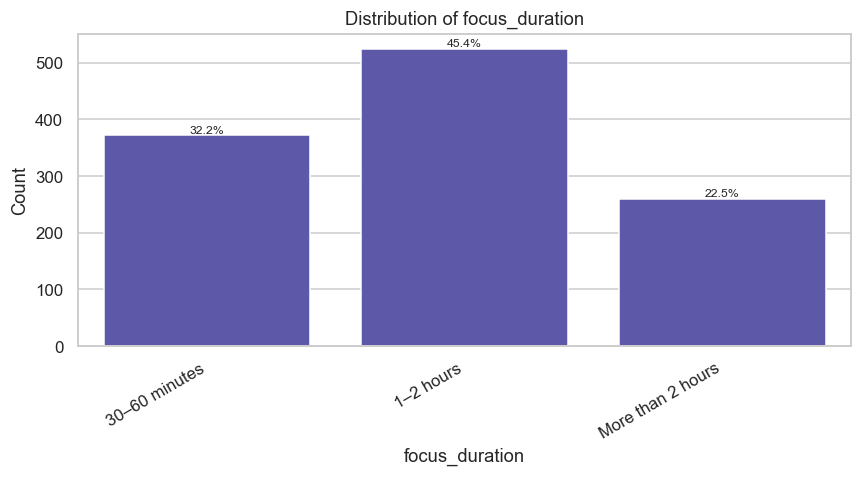

2026-06-22 22:54:11,213 | INFO | Saved plot -> EDA_01_univariate_screen_time_non_study.png


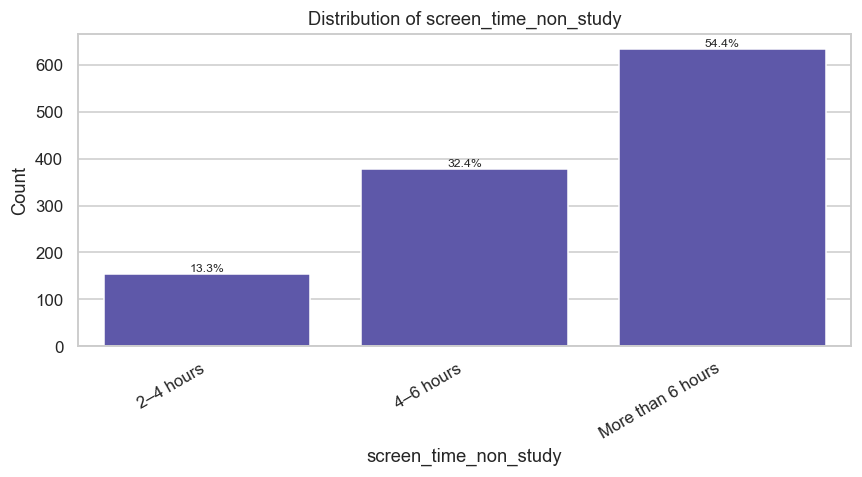

2026-06-22 22:54:11,319 | INFO | Saved plot -> EDA_01_univariate_study_consistency.png


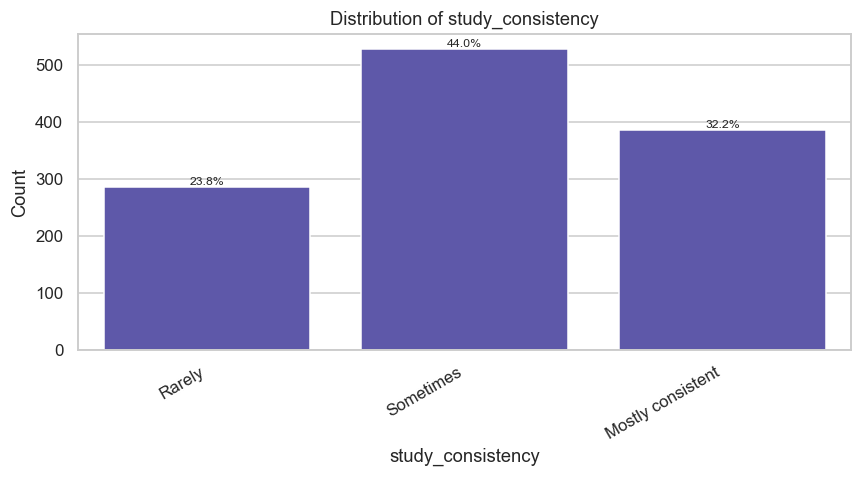

2026-06-22 22:54:11,428 | INFO | Saved plot -> EDA_01_univariate_tasks_on_time.png


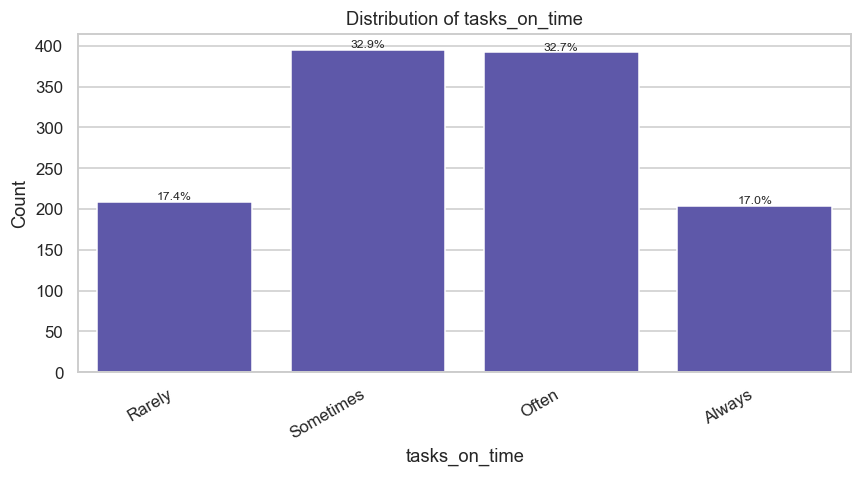

2026-06-22 22:54:11,539 | INFO | Saved plot -> EDA_01_univariate_assignments_on_time.png


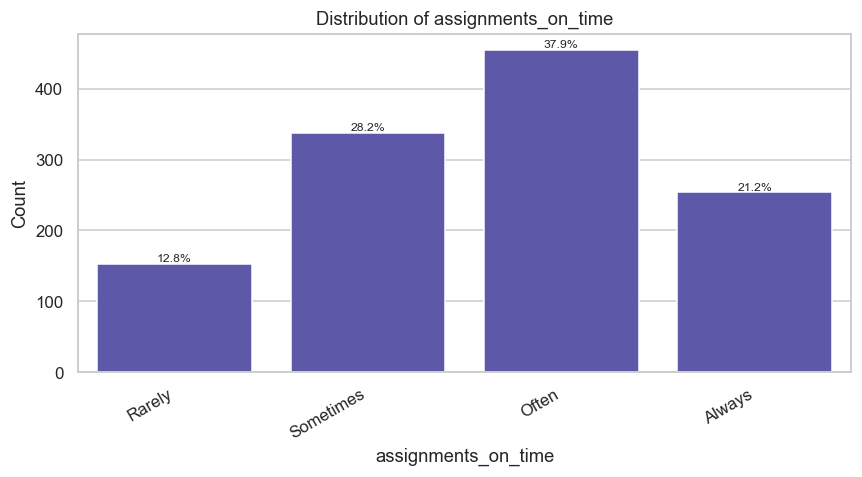

2026-06-22 22:54:11,650 | INFO | Saved plot -> EDA_01_univariate_preparation_status.png


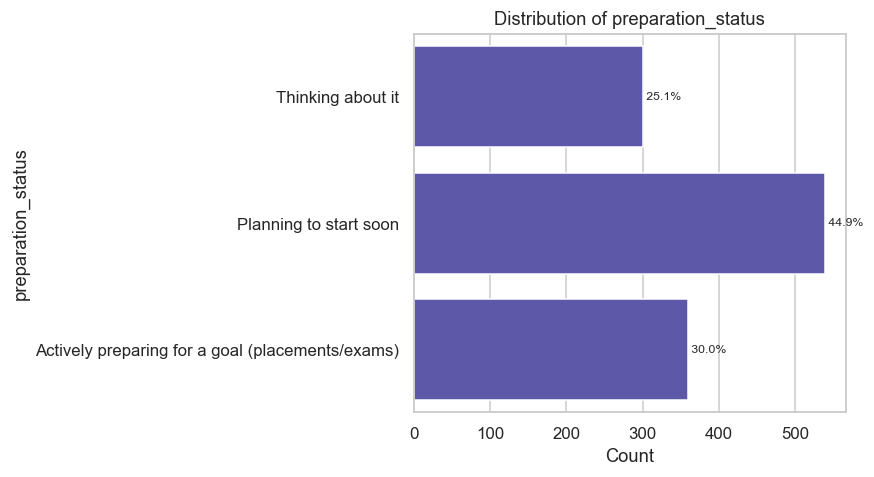

2026-06-22 22:54:11,756 | INFO | Saved plot -> EDA_01_univariate_career_goal_clarity.png


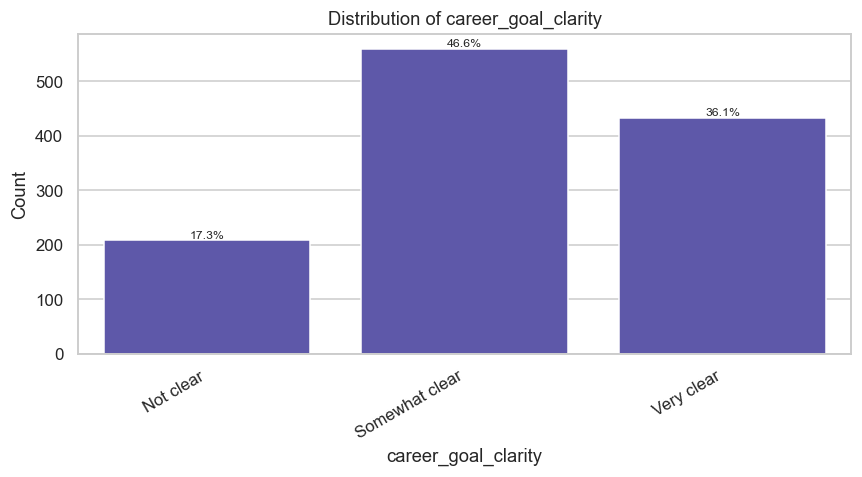

2026-06-22 22:54:11,865 | INFO | Saved plot -> EDA_01_univariate_sleepy_during_study.png


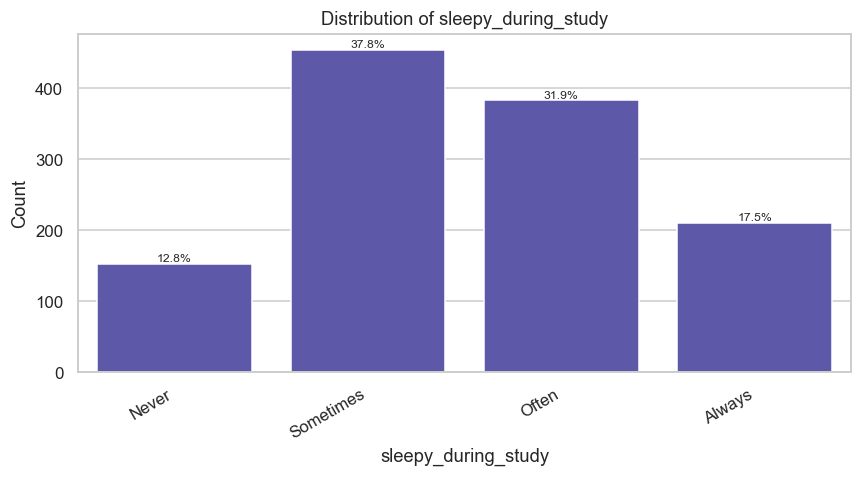

2026-06-22 22:54:11,967 | INFO | Saved plot -> EDA_01_univariate_sleep_hours.png


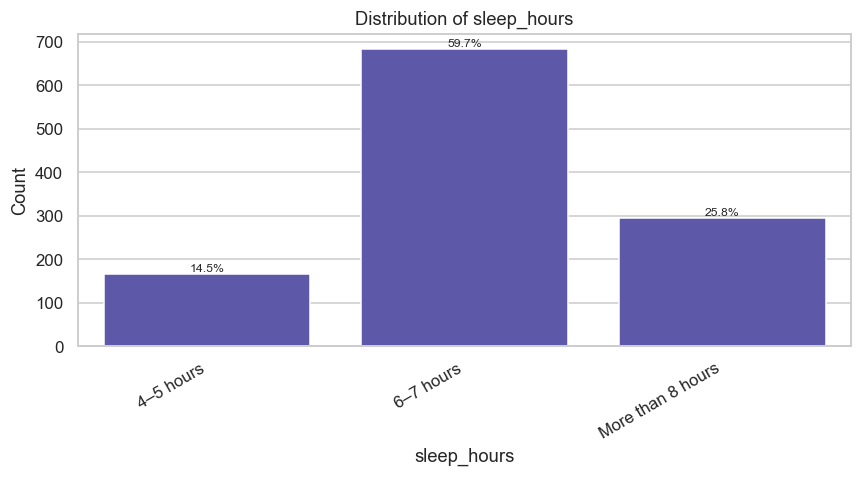

2026-06-22 22:54:12,118 | INFO | Saved plot -> EDA_01_univariate_online_courses.png


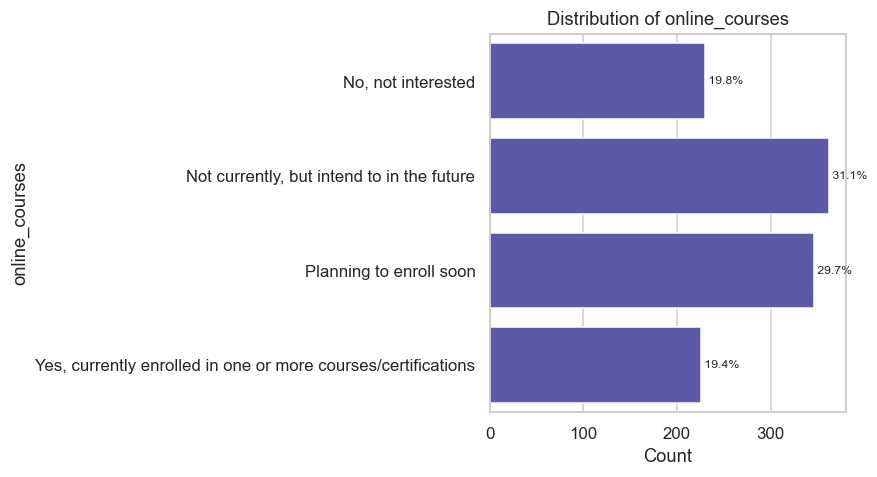

2026-06-22 22:54:12,229 | INFO | Saved plot -> EDA_01_univariate_projects_internships.png


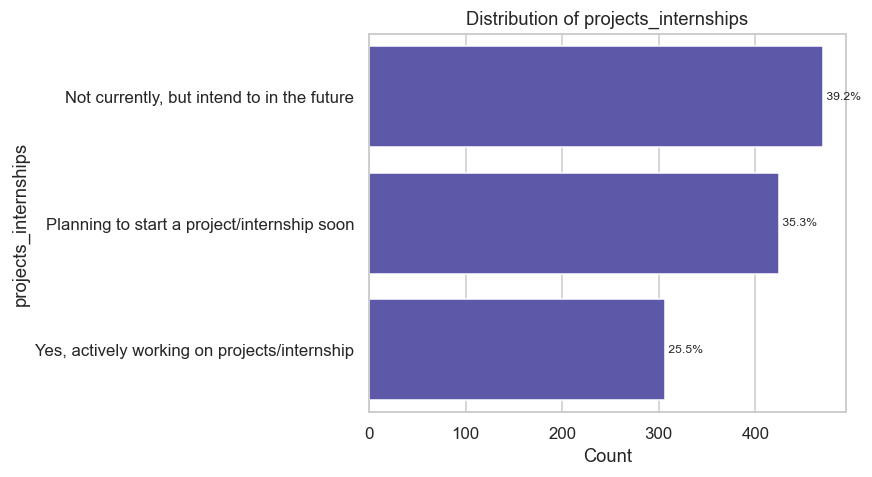

2026-06-22 22:54:12,349 | INFO | Saved plot -> EDA_01_univariate_programming_foundation.png


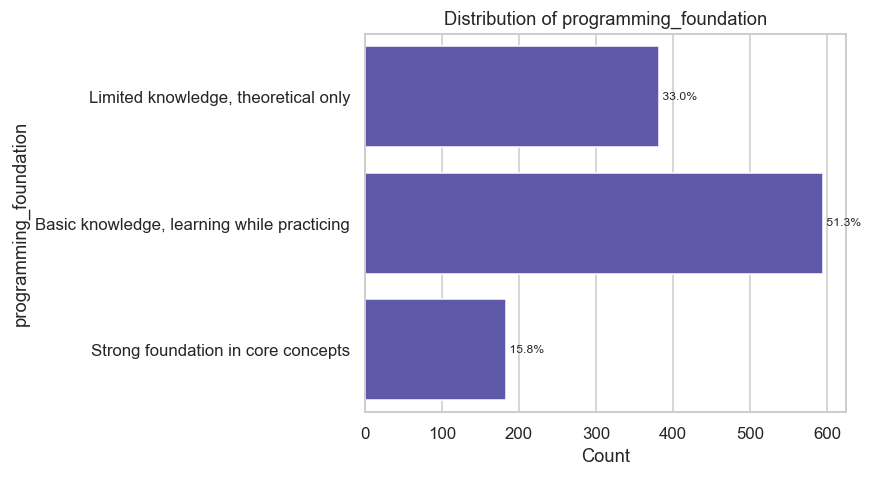

2026-06-22 22:54:12,464 | INFO | Saved plot -> EDA_01_univariate_events_participation.png


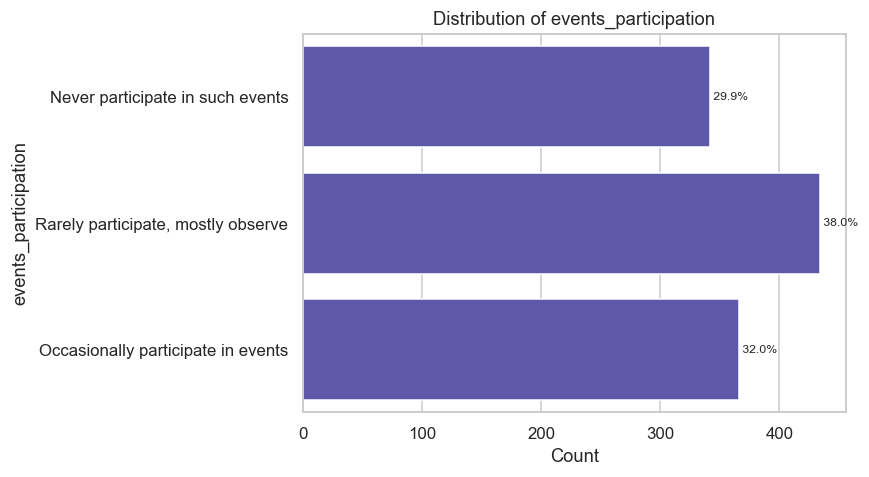

2026-06-22 22:54:12,590 | INFO | Saved plot -> EDA_01_univariate_external_resources.png


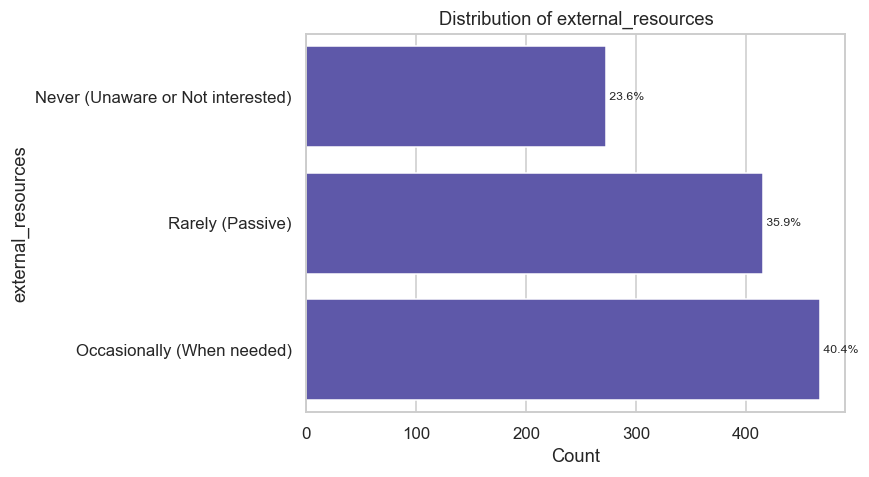

2026-06-22 22:54:12,751 | INFO | Saved plot -> EDA_01_univariate_external_pressure.png


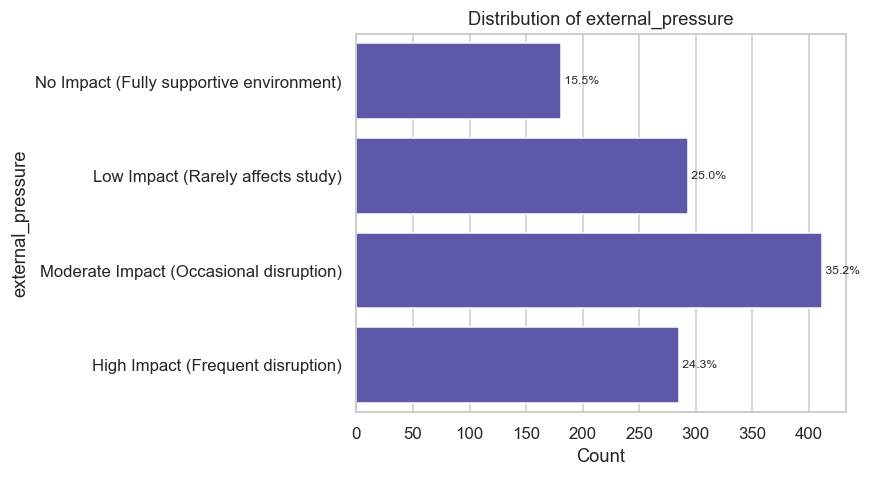

2026-06-22 22:54:12,871 | INFO | Saved plot -> EDA_01_univariate_procrastination_level.png


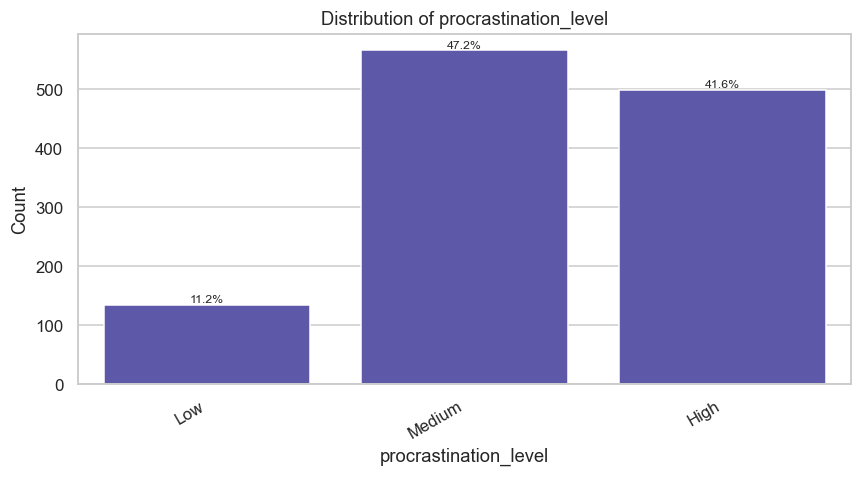

2026-06-22 22:54:12,990 | INFO | Saved plot -> EDA_01_univariate_year_class.png


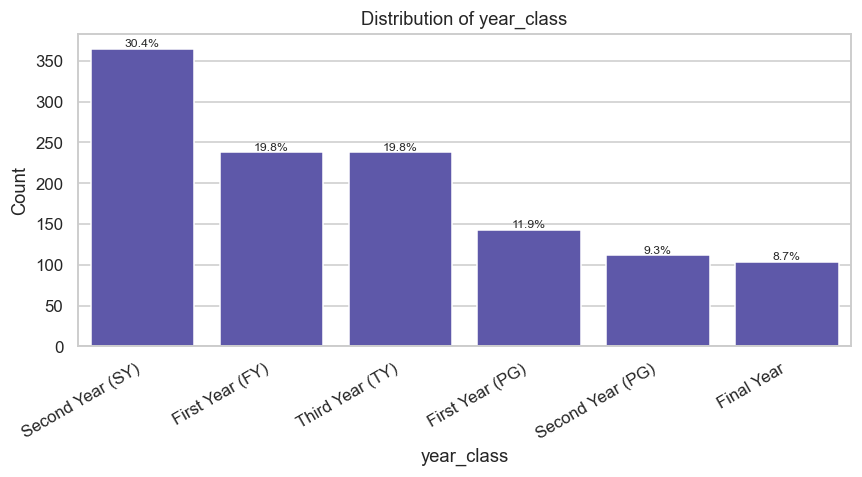

2026-06-22 22:54:13,127 | INFO | Saved plot -> EDA_01_univariate_program_stream.png


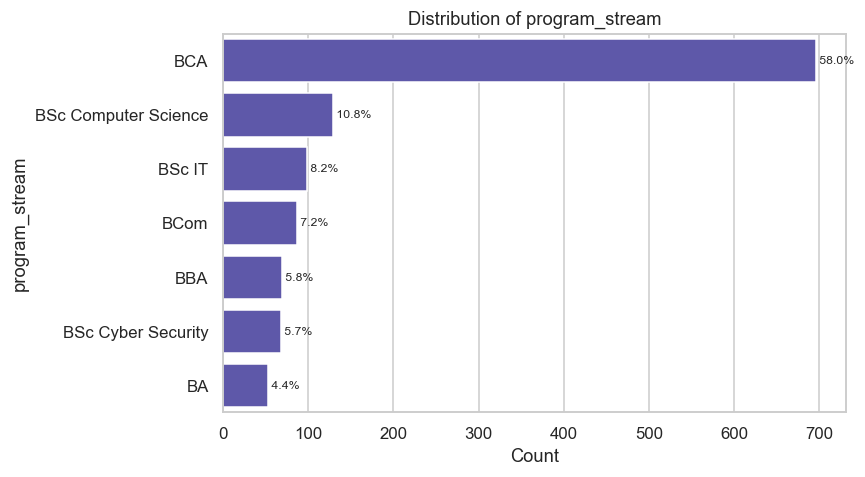

2026-06-22 22:54:13,255 | INFO | Saved plot -> EDA_01_univariate_main_distractor.png


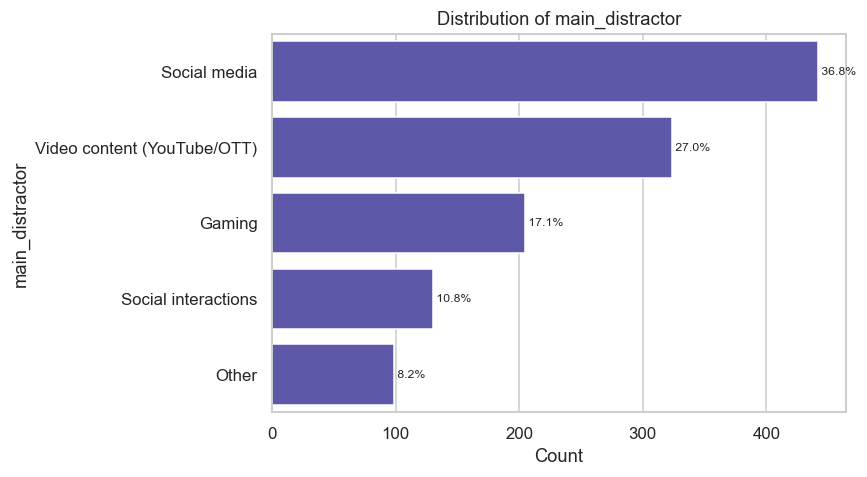

2026-06-22 22:54:13,368 | INFO | Saved plot -> EDA_01_univariate_skills_developing.png


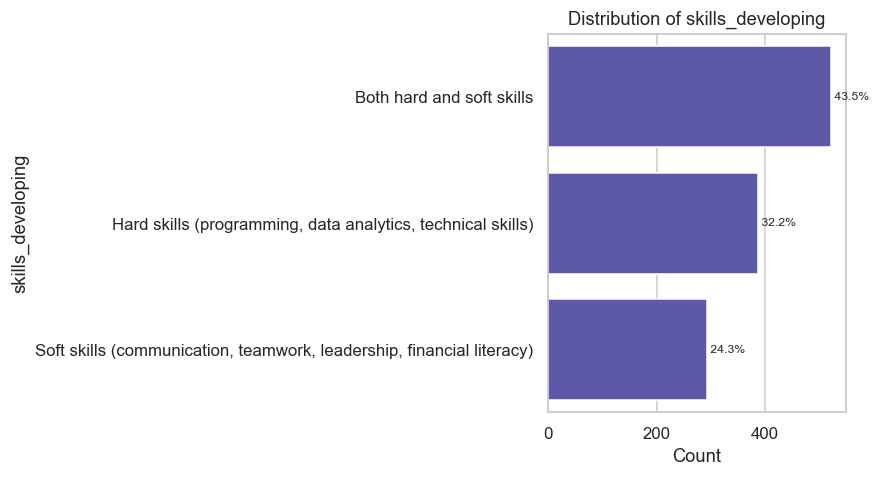

2026-06-22 22:54:13,494 | INFO | Saved plot -> EDA_01_univariate_career_interest.png


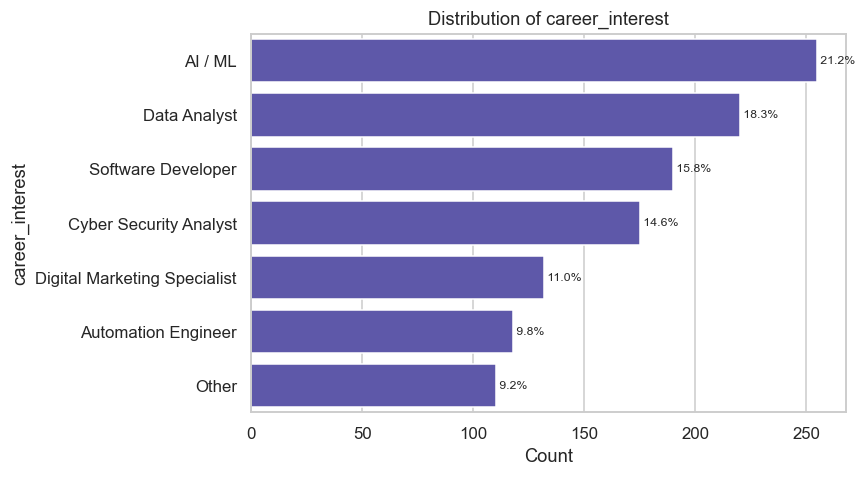

2026-06-22 22:54:13,621 | INFO | Saved plot -> EDA_01_univariate_strongest_asset.png


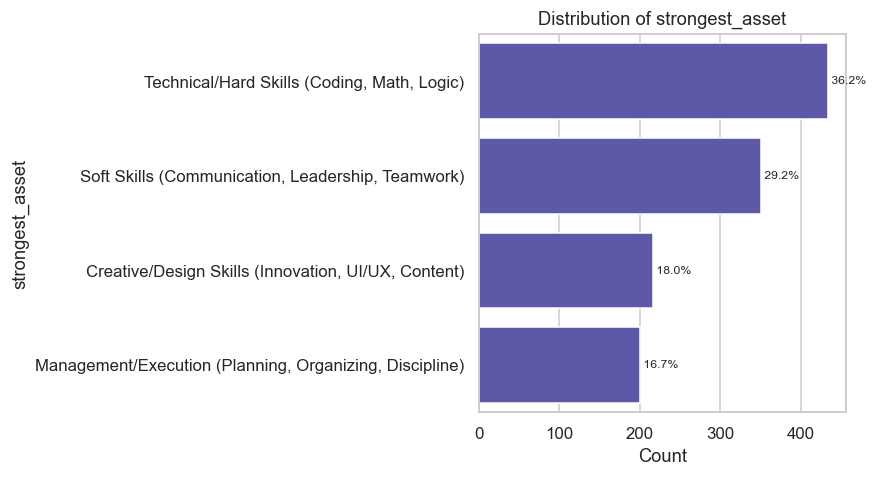

2026-06-22 22:54:13,743 | INFO | Saved plot -> EDA_01_univariate_internal_barrier.png


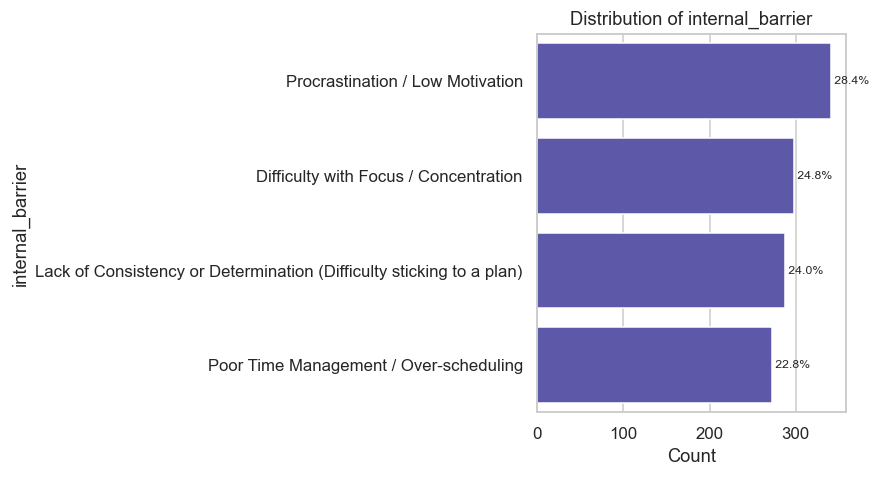

In [5]:
for column in ORDINAL_FEATURES:
    plot_categorical_distribution(column, order=config.DS1_ORDINAL_FEATURES[column])

plot_categorical_distribution(
    config.PROCRASTINATION_FEATURE, order=config.PROCRASTINATION_LEVELS
)

for column in NOMINAL_FEATURES:
    plot_categorical_distribution(column)

## 4. Target variable distribution (EDA Step 3)

Class balance of `performance_risk_level`. If the smallest class falls below the
`MINORITY_CLASS_THRESHOLD` defined in config (25%), this is flagged here — it is
the trigger for applying SMOTE to the training split during classification
(which will be done in a later step not now).

2026-06-22 22:54:13,863 | INFO | Saved plot -> EDA_01_target_distribution.png


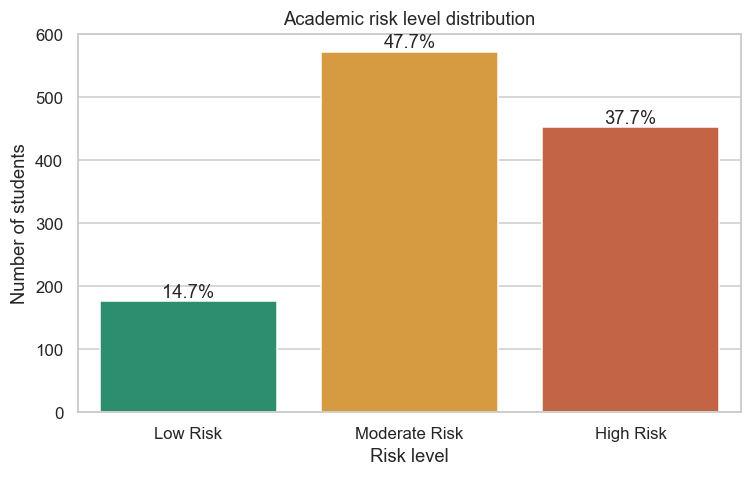

2026-06-22 22:54:13,900 | INFO | Low Risk: 176 students (14.67%)


2026-06-22 22:54:13,900 | INFO | Moderate Risk: 572 students (47.67%)


2026-06-22 22:54:13,901 | INFO | High Risk: 452 students (37.67%)


2026-06-22 22:54:13,901 | WARNING | Smallest class is 14.67% (< 25%): SMOTE will be applied to the classification training split in Step 9.


In [6]:
risk_counts = df[TARGET].value_counts().reindex(config.RISK_LEVELS)
risk_pct = (risk_counts / len(df) * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(
    x=config.RISK_LEVELS,
    y=risk_counts.values,
    hue=config.RISK_LEVELS,
    palette=config.RISK_PALETTE,
    legend=False,
    ax=ax,
)
for i, value in enumerate(risk_counts.values):
    ax.text(i, value, f"{risk_pct.values[i]:.1f}%", ha="center", va="bottom")
ax.set_title("Academic risk level distribution")
ax.set_xlabel("Risk level")
ax.set_ylabel("Number of students")
plt.tight_layout()
save_plot(fig, "EDA_01_target_distribution.png")

for level in config.RISK_LEVELS:
    logger.info("%s: %d students (%.2f%%)", level, int(risk_counts[level]), risk_pct[level])

smallest = risk_pct.min()
threshold_pct = config.MINORITY_CLASS_THRESHOLD * 100
if smallest < threshold_pct:
    logger.warning(
        "Smallest class is %.2f%% (< %.0f%%): SMOTE will be applied to the "
        "classification training split in Step 9.",
        smallest,
        threshold_pct,
    )
else:
    logger.info(
        "All classes are >= %.0f%%; SMOTE is not strictly required.", threshold_pct
    )

## 5. Bivariate analysis (EDA Step 4)

Relationships between key behavioral features and academic risk. Because several
DS1 features are stored as ordinal bands rather than continuous numbers, the
study-hours and sleep plots use the ordinal codes (0 = lowest band). The
hackathon-participation requirement is served by `events_participation`, the
real dataset's event-engagement feature.

2026-06-22 22:54:13,989 | INFO | Saved plot -> EDA_01_bivariate_studyhours_risk.png


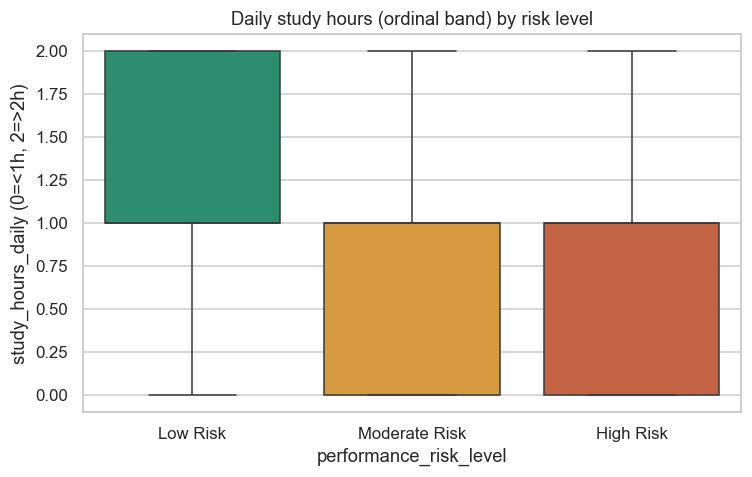

2026-06-22 22:54:14,108 | INFO | Saved plot -> EDA_01_bivariate_sleep_risk.png


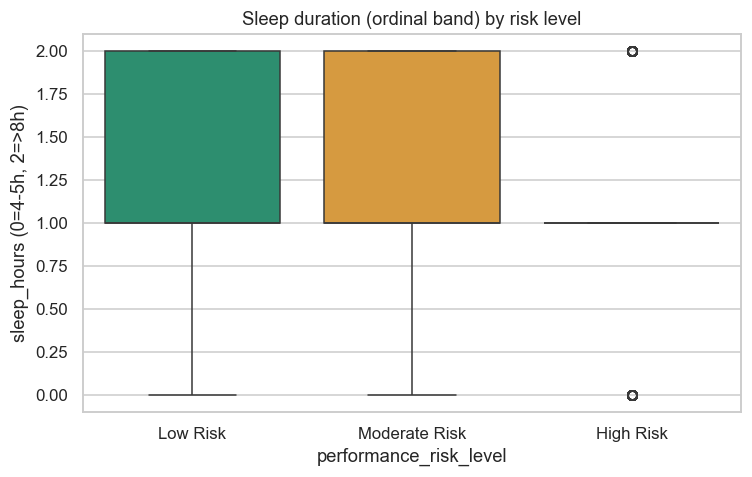

2026-06-22 22:54:14,254 | INFO | Saved plot -> EDA_01_bivariate_procrastination_consistency.png


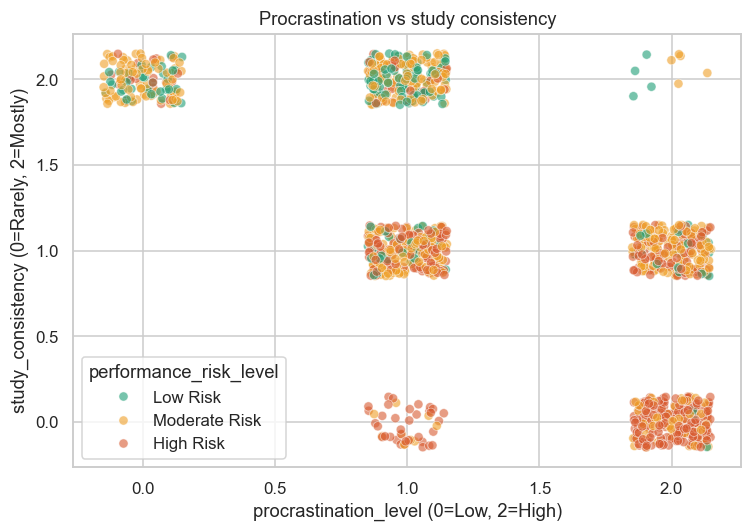

2026-06-22 22:54:14,404 | INFO | Saved plot -> EDA_01_bivariate_careerclarity_risk.png


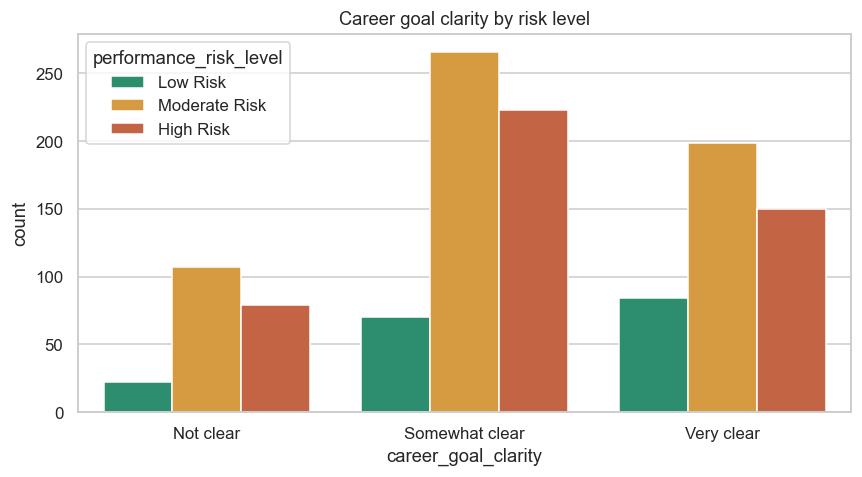

2026-06-22 22:54:14,585 | INFO | Saved plot -> EDA_01_bivariate_events_risk.png


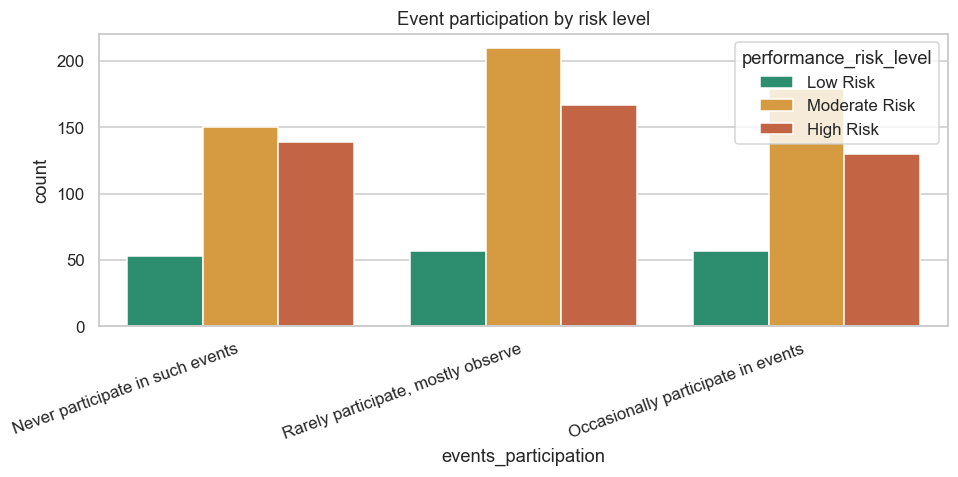

2026-06-22 22:54:14,749 | INFO | Saved plot -> EDA_01_bivariate_screentime_productivity.png


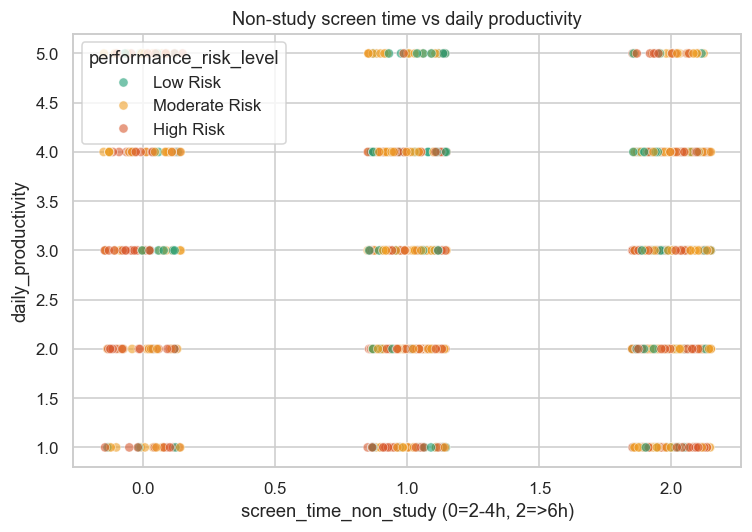

In [7]:
def jitter(series: pd.Series, width: float = 0.15) -> np.ndarray:
    """Add uniform jitter so overlapping ordinal points are visible."""
    return series + np.random.uniform(-width, width, size=len(series))


# Study hours (ordinal code) by risk level.
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(
    x=df[TARGET], y=numeric_df["study_hours_daily"], order=config.RISK_LEVELS,
    hue=df[TARGET], palette=config.RISK_PALETTE, legend=False, ax=ax,
)
ax.set_title("Daily study hours (ordinal band) by risk level")
ax.set_ylabel("study_hours_daily (0=<1h, 2=>2h)")
plt.tight_layout()
save_plot(fig, "EDA_01_bivariate_studyhours_risk.png")

# Sleep (ordinal code) by risk level.
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(
    x=df[TARGET], y=numeric_df["sleep_hours"], order=config.RISK_LEVELS,
    hue=df[TARGET], palette=config.RISK_PALETTE, legend=False, ax=ax,
)
ax.set_title("Sleep duration (ordinal band) by risk level")
ax.set_ylabel("sleep_hours (0=4-5h, 2=>8h)")
plt.tight_layout()
save_plot(fig, "EDA_01_bivariate_sleep_risk.png")

# Procrastination vs study consistency, coloured by risk.
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    x=jitter(numeric_df[config.PROCRASTINATION_FEATURE]),
    y=jitter(numeric_df["study_consistency"]),
    hue=df[TARGET], hue_order=config.RISK_LEVELS, palette=config.RISK_PALETTE,
    alpha=0.6, ax=ax,
)
ax.set_title("Procrastination vs study consistency")
ax.set_xlabel("procrastination_level (0=Low, 2=High)")
ax.set_ylabel("study_consistency (0=Rarely, 2=Mostly)")
plt.tight_layout()
save_plot(fig, "EDA_01_bivariate_procrastination_consistency.png")

# Career goal clarity by risk.
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.countplot(
    data=df, x="career_goal_clarity", hue=TARGET,
    order=config.DS1_ORDINAL_FEATURES["career_goal_clarity"],
    hue_order=config.RISK_LEVELS, palette=config.RISK_PALETTE, ax=ax,
)
ax.set_title("Career goal clarity by risk level")
plt.tight_layout()
save_plot(fig, "EDA_01_bivariate_careerclarity_risk.png")

# Event participation by risk (hackathon-engagement proxy).
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.countplot(
    data=df, x="events_participation", hue=TARGET,
    order=config.DS1_ORDINAL_FEATURES["events_participation"],
    hue_order=config.RISK_LEVELS, palette=config.RISK_PALETTE, ax=ax,
)
ax.set_title("Event participation by risk level")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
save_plot(fig, "EDA_01_bivariate_events_risk.png")

# Screen time vs productivity, coloured by risk.
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    x=jitter(numeric_df["screen_time_non_study"]), y=df["daily_productivity"],
    hue=df[TARGET], hue_order=config.RISK_LEVELS, palette=config.RISK_PALETTE,
    alpha=0.6, ax=ax,
)
ax.set_title("Non-study screen time vs daily productivity")
ax.set_xlabel("screen_time_non_study (0=2-4h, 2=>6h)")
ax.set_ylabel("daily_productivity")
plt.tight_layout()
save_plot(fig, "EDA_01_bivariate_screentime_productivity.png")

## 6. Correlation analysis (EDA Step 5)

Pearson correlation across all numeric and ordinal-encoded features plus the
encoded risk label. The heatmap gives the global picture; below it every pair
with absolute correlation at or above 0.5 is listed and interpreted.

2026-06-22 22:54:15,464 | INFO | Saved plot -> EDA_01_correlation_heatmap.png


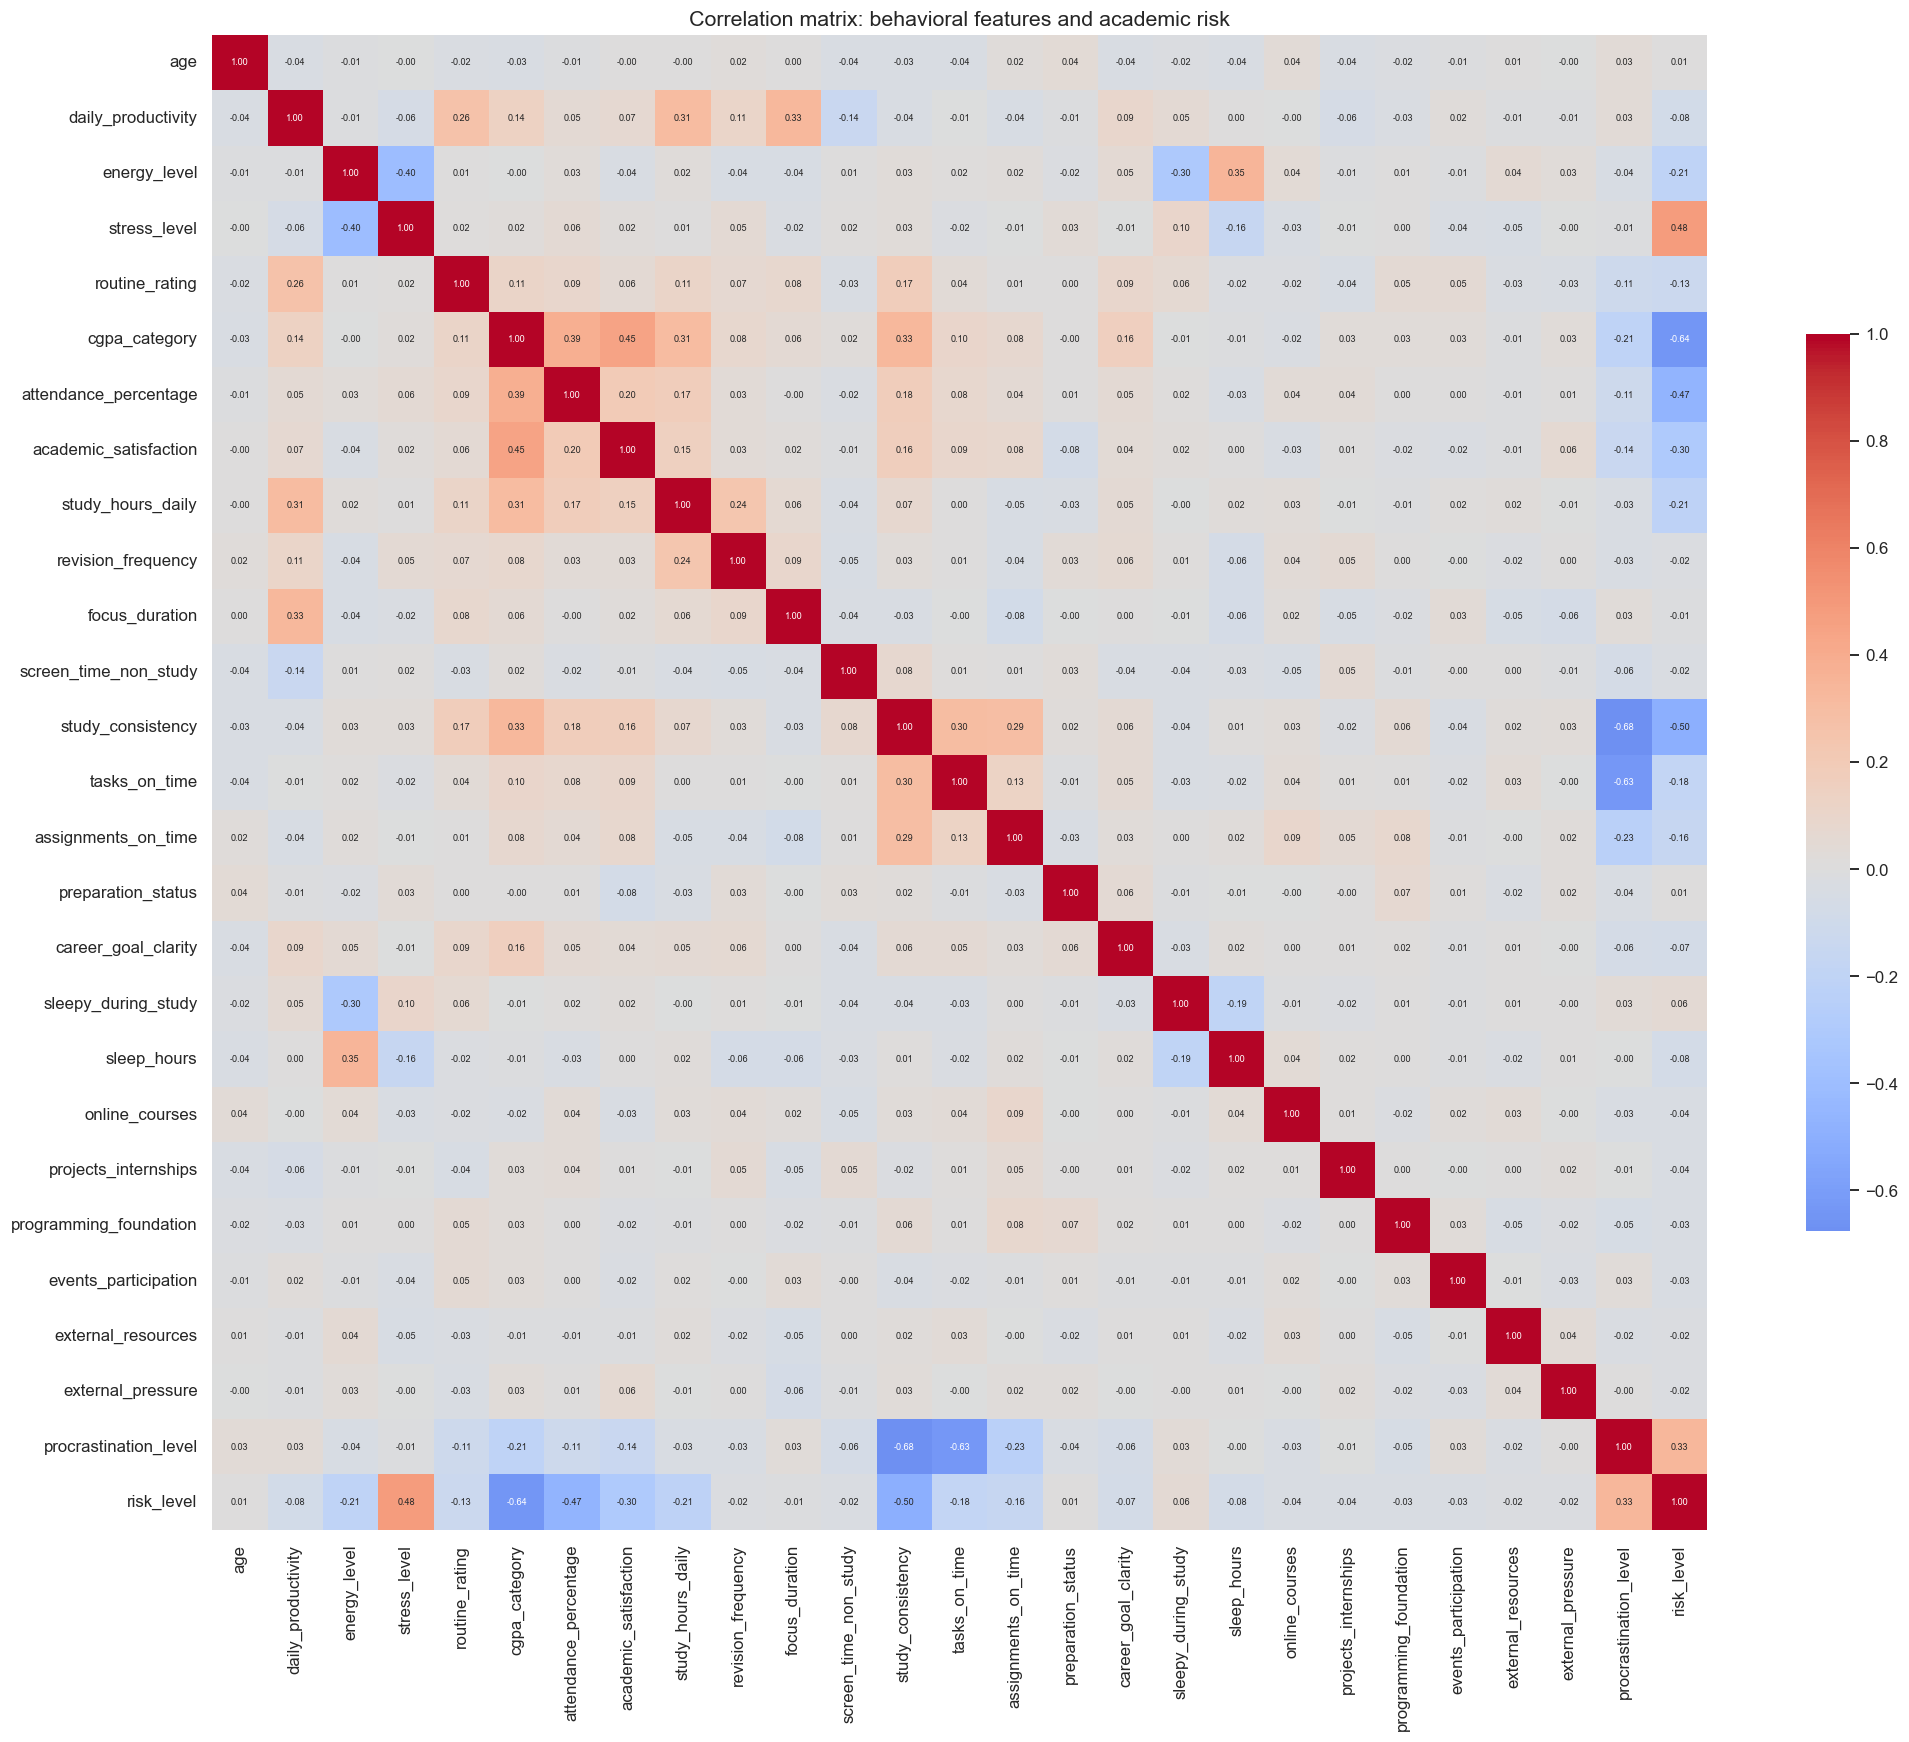

2026-06-22 22:54:15,836 | INFO | |r|>=0.5: study_consistency <-> procrastination_level : r=-0.676


2026-06-22 22:54:15,836 | INFO | |r|>=0.5: cgpa_category <-> risk_level : r=-0.638


2026-06-22 22:54:15,837 | INFO | |r|>=0.5: tasks_on_time <-> procrastination_level : r=-0.632


2026-06-22 22:54:15,837 | INFO | |r|>=0.5: study_consistency <-> risk_level : r=-0.503


,feature_a,feature_b,r
0,study_consistency,procrastination_level,-0.676
1,cgpa_category,risk_level,-0.638
2,tasks_on_time,procrastination_level,-0.632
3,study_consistency,risk_level,-0.503


In [8]:
corr = numeric_df.assign(risk_level=risk_code).corr()

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    annot_kws={"size": 6}, square=True, cbar_kws={"shrink": 0.6}, ax=ax,
)
ax.set_title("Correlation matrix: behavioral features and academic risk", fontsize=14)
plt.tight_layout()
save_plot(fig, "EDA_01_correlation_heatmap.png")

columns = corr.columns
strong_pairs = []
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        coefficient = corr.iloc[i, j]
        if abs(coefficient) >= 0.5:
            strong_pairs.append(
                {"feature_a": columns[i], "feature_b": columns[j], "r": round(coefficient, 3)}
            )

strong_pairs_df = pd.DataFrame(strong_pairs).sort_values(
    "r", key=lambda s: s.abs(), ascending=False
).reset_index(drop=True)
for _, row in strong_pairs_df.iterrows():
    logger.info("|r|>=0.5: %s <-> %s : r=%.3f", row.feature_a, row.feature_b, row.r)
strong_pairs_df

## 7. Performance segmentation (EDA Step 6)

Mean of every numeric and ordinal-encoded feature within each risk tier. The
full table exposes every feature; the grouped bar chart focuses on the
behavioral clustering features, min–max normalised per feature so tiers are
comparable on one axis.

In [9]:
tier_means = (
    numeric_df.groupby(df[TARGET], observed=True)
    .mean()
    .reindex(config.RISK_LEVELS)
    .round(3)
)
tier_means

,age,daily_productivity,energy_level,stress_level,routine_rating,cgpa_category,attendance_percentage,academic_satisfaction,study_hours_daily,revision_frequency,...,career_goal_clarity,sleepy_during_study,sleep_hours,online_courses,projects_internships,programming_foundation,events_participation,external_resources,external_pressure,procrastination_level
performance_risk_level,,,,,,,,,,,,,,,,,,,,,
Low Risk,20.795,2.884,3.600,2.035,2.267,2.449,3.142,2.795,1.091,1.193,...,1.352,1.477,1.160,1.491,0.932,0.780,1.024,1.167,1.708,0.932
Moderate Risk,20.781,2.704,3.336,3.011,2.149,1.657,2.469,2.416,0.867,1.179,...,1.161,1.507,1.152,1.540,0.862,0.885,1.054,1.189,1.698,1.215
High Risk,20.845,2.588,2.943,3.768,1.986,0.688,1.471,1.869,0.646,1.145,...,1.157,1.611,1.044,1.421,0.838,0.774,0.979,1.141,1.657,1.560


2026-06-22 22:54:16,015 | INFO | Saved plot -> EDA_01_segmentation_behavioral.png


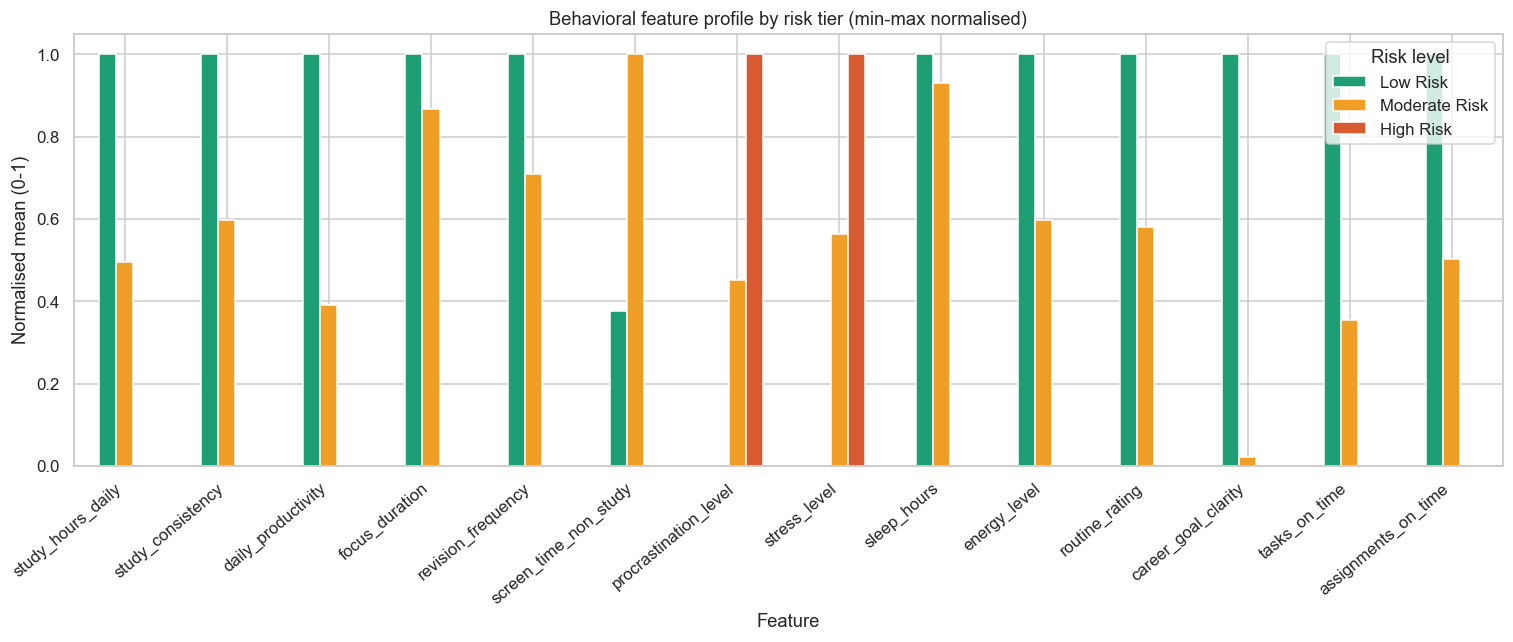

In [10]:
behavioral = config.DS1_CLUSTER_FEATURES
subset = tier_means[behavioral]
normalised = (subset - subset.min()) / (subset.max() - subset.min())

ax = normalised.T.plot(
    kind="bar",
    figsize=(14, 6),
    color=[config.RISK_PALETTE[level] for level in normalised.T.columns],
)
ax.set_title("Behavioral feature profile by risk tier (min-max normalised)")
ax.set_ylabel("Normalised mean (0-1)")
ax.set_xlabel("Feature")
ax.legend(title="Risk level")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
save_plot(ax.get_figure(), "EDA_01_segmentation_behavioral.png")

## 8. Outlier analysis (EDA Step 7)

IQR and z-score outlier detection for the natively numeric features. The ordinal
features are bounded by construction and not subject to outlier removal, so they
are excluded here. A decision is recorded per feature.

In [11]:
outlier_rows = []
for column in NATIVE_NUMERIC:
    values = df[column].dropna()
    q1, q3 = values.quantile(0.25), values.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_outliers = int(((values < lower) | (values > upper)).sum())
    z_scores = (values - values.mean()) / values.std(ddof=0)
    z_outliers = int((z_scores.abs() > 3).sum())
    outlier_rows.append(
        {
            "feature": column,
            "iqr_lower": round(lower, 2),
            "iqr_upper": round(upper, 2),
            "iqr_outliers": iqr_outliers,
            "z_outliers": z_outliers,
            "pct_of_values": round(iqr_outliers / len(values) * 100, 2),
        }
    )

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary

,feature,iqr_lower,iqr_upper,iqr_outliers,z_outliers,pct_of_values
0,age,14.5,26.5,0,0,0.00
1,daily_productivity,0.5,4.5,87,0,7.46
2,energy_level,-1.0,7.0,0,0,0.00
3,stress_level,-1.0,7.0,0,0,0.00
4,routine_rating,-2.0,6.0,0,0,0.00


**Outlier decisions.** `daily_productivity`, `energy_level`, `stress_level`,
and `routine_rating` are bounded 1–5 self-report scales: any IQR-flagged values
are legitimate responses at the ends of the scale, so they are **kept**. `age`
is a real demographic with a naturally narrow range; any high-age values are
plausible mature students and are **kept** rather than removed, since dropping
them would discard valid records. No outlier removal is applied to this dataset;
this decision is revisited only if a specific feature shows implausible values
during modelling.

## 9. Violin plots (EDA Step 8)

Violin plots reveal the full distribution shape of each behavioral signal across
the three risk tiers, using the Firasa risk palette (green / amber / coral for
Low / Moderate / High). These are the most diagnostic visuals for separating the
tiers.

2026-06-22 22:54:16,236 | INFO | Saved plot -> EDA_01_violin_age.png


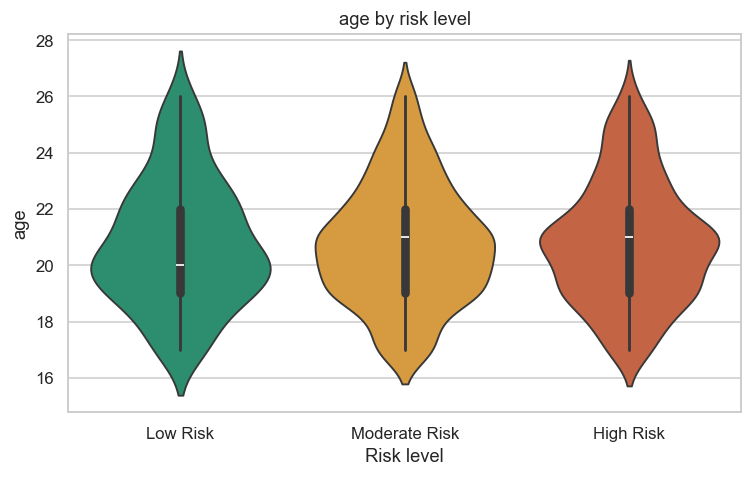

2026-06-22 22:54:16,352 | INFO | Saved plot -> EDA_01_violin_daily_productivity.png


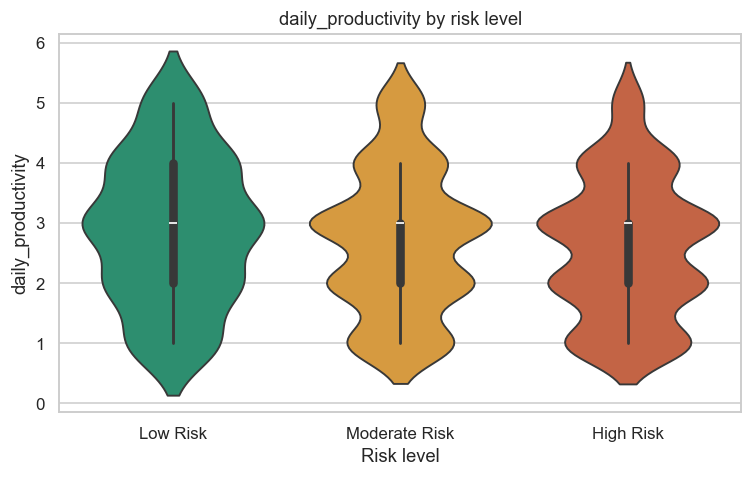

2026-06-22 22:54:16,526 | INFO | Saved plot -> EDA_01_violin_energy_level.png


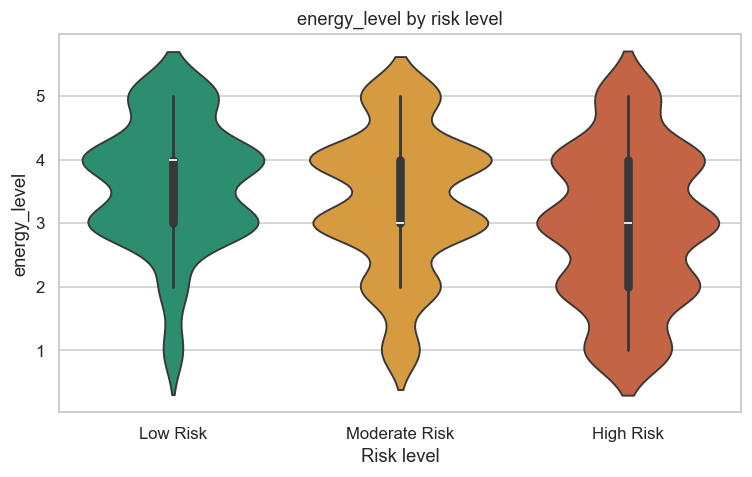

2026-06-22 22:54:16,638 | INFO | Saved plot -> EDA_01_violin_stress_level.png


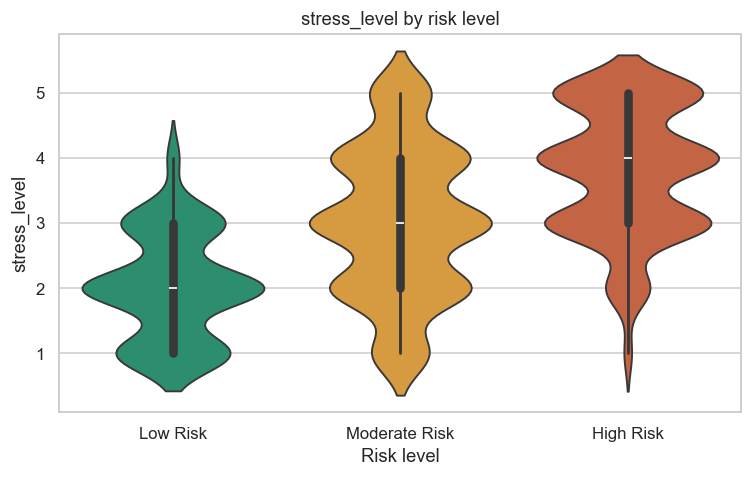

2026-06-22 22:54:16,757 | INFO | Saved plot -> EDA_01_violin_routine_rating.png


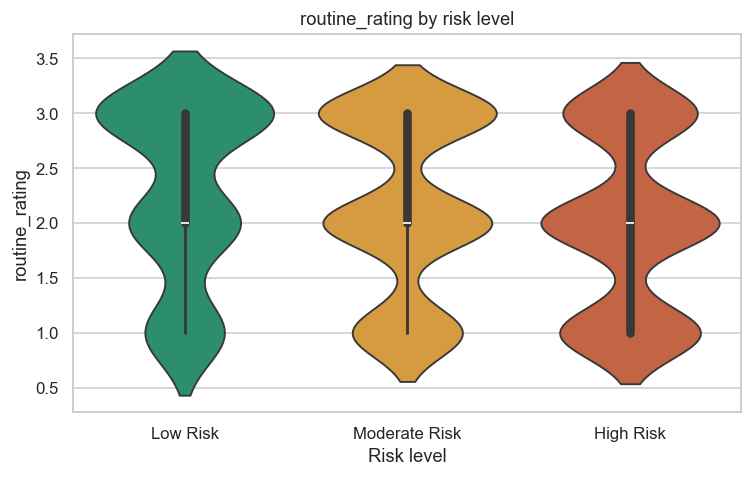

2026-06-22 22:54:16,878 | INFO | Saved plot -> EDA_01_violin_procrastination_level.png


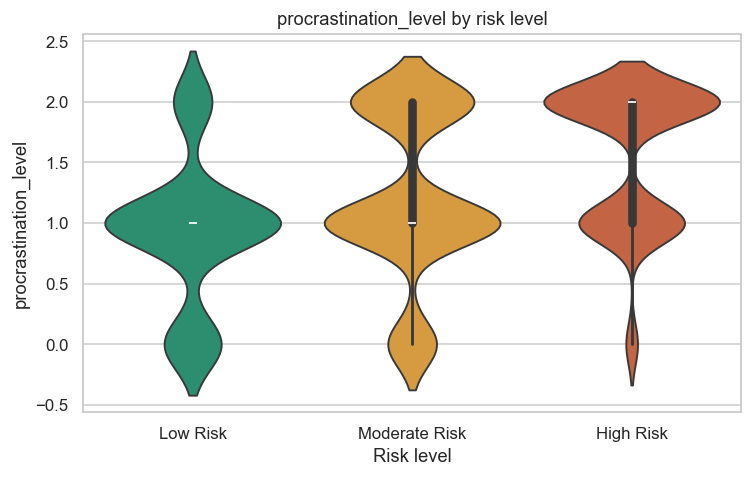

2026-06-22 22:54:16,996 | INFO | Saved plot -> EDA_01_violin_study_hours_daily.png


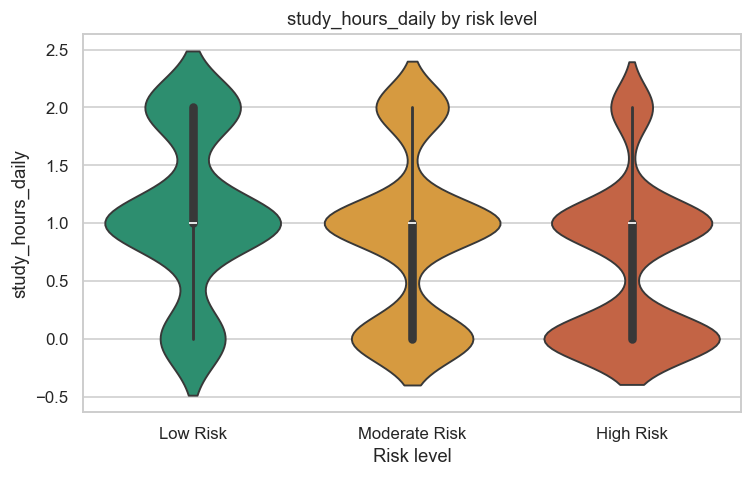

2026-06-22 22:54:17,140 | INFO | Saved plot -> EDA_01_violin_study_consistency.png


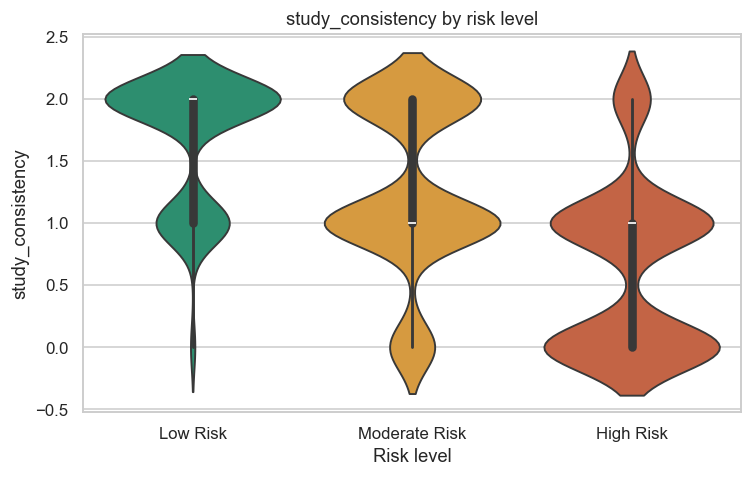

2026-06-22 22:54:17,261 | INFO | Saved plot -> EDA_01_violin_screen_time_non_study.png


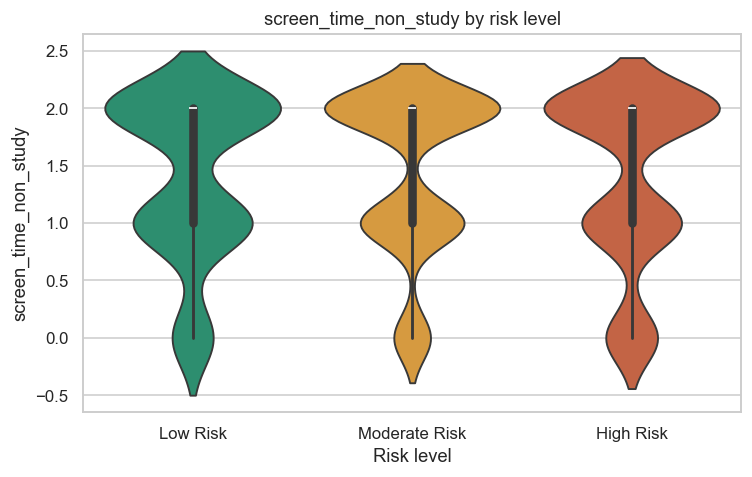

In [12]:
violin_features = NATIVE_NUMERIC + [
    config.PROCRASTINATION_FEATURE,
    "study_hours_daily",
    "study_consistency",
    "screen_time_non_study",
]

for column in violin_features:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    sns.violinplot(
        x=df[TARGET], y=numeric_df[column], order=config.RISK_LEVELS,
        hue=df[TARGET], palette=config.RISK_PALETTE, legend=False, ax=ax,
    )
    ax.set_title(f"{column} by risk level")
    ax.set_xlabel("Risk level")
    ax.set_ylabel(column)
    plt.tight_layout()
    save_plot(fig, f"EDA_01_violin_{column}.png")

## 10. Written insights (EDA Step 9)

Seven data-backed insights concluded directly from the dataset. Every figure is
calculated at runtime, so these statements stay accurate even if later the data changes.

In [13]:
def high_risk_rate_by(column: str) -> pd.Series:
    """Return the share of High Risk students within each level of a feature."""
    return df.groupby(column, observed=True)[TARGET].apply(
        lambda values: (values == "High Risk").mean()
    )


insights = []

study_rate = high_risk_rate_by("study_hours_daily")
rate_low = study_rate.get("Less than 1 hour", np.nan)
rate_high = study_rate.get("More than 2 hours", np.nan)
ratio = rate_low / rate_high if rate_high else np.nan
insights.append(
    f"Students studying 'Less than 1 hour' daily are {ratio:.1f}x more likely to be "
    f"High Risk than those studying 'More than 2 hours' "
    f"({rate_low * 100:.1f}% vs {rate_high * 100:.1f}%)."
)

proc_rate = high_risk_rate_by(config.PROCRASTINATION_FEATURE)
insights.append(
    f"High-procrastination students are High Risk {proc_rate.get('High', np.nan) * 100:.1f}% "
    f"of the time, versus {proc_rate.get('Low', np.nan) * 100:.1f}% for low-procrastination students."
)

clarity_rate = high_risk_rate_by("career_goal_clarity")
insights.append(
    f"Students with no career clarity are High Risk {clarity_rate.get('Not clear', np.nan) * 100:.1f}%, "
    f"versus {clarity_rate.get('Very clear', np.nan) * 100:.1f}% for those with very clear goals."
)

proc_corr = numeric_df[config.PROCRASTINATION_FEATURE].corr(risk_code)
insights.append(
    f"The derived procrastination_level correlates r={proc_corr:.2f} with academic risk, "
    f"among the strongest single-feature signals."
)

behavioral_corr = numeric_df.corr()
best_pair, best_value = None, 0.0
pair_columns = behavioral_corr.columns
for i in range(len(pair_columns)):
    for j in range(i + 1, len(pair_columns)):
        coefficient = behavioral_corr.iloc[i, j]
        if abs(coefficient) > abs(best_value):
            best_pair, best_value = (pair_columns[i], pair_columns[j]), coefficient
insights.append(
    f"The strongest behavioral feature pairing is {best_pair[0]} and {best_pair[1]} "
    f"(r={best_value:.2f})."
)

prod_high_screen = df.loc[df["screen_time_non_study"] == "More than 6 hours", "daily_productivity"].mean()
prod_low_screen = df.loc[df["screen_time_non_study"] == "2–4 hours", "daily_productivity"].mean()
insights.append(
    f"Students with more than 6 hours of non-study screen time average "
    f"{prod_high_screen:.2f} productivity, versus {prod_low_screen:.2f} for the 2-4 hour group."
)

stress_high = df.loc[df[TARGET] == "High Risk", "stress_level"].mean()
stress_low = df.loc[df[TARGET] == "Low Risk", "stress_level"].mean()
insights.append(
    f"Mean self-reported stress is {stress_high:.2f} for High Risk students "
    f"versus {stress_low:.2f} for Low Risk students."
)

for number, statement in enumerate(insights, start=1):
    logger.info("Insight %d: %s", number, statement)

2026-06-22 22:54:17,319 | INFO | Insight 1: Students studying 'Less than 1 hour' daily are 2.1x more likely to be High Risk than those studying 'More than 2 hours' (48.6% vs 23.6%).


2026-06-22 22:54:17,319 | INFO | Insight 2: High-procrastination students are High Risk 54.3% of the time, versus 13.3% for low-procrastination students.


2026-06-22 22:54:17,319 | INFO | Insight 3: Students with no career clarity are High Risk 38.0%, versus 34.6% for those with very clear goals.


2026-06-22 22:54:17,319 | INFO | Insight 4: The derived procrastination_level correlates r=0.33 with academic risk, among the strongest single-feature signals.


2026-06-22 22:54:17,319 | INFO | Insight 5: The strongest behavioral feature pairing is study_consistency and procrastination_level (r=-0.68).


2026-06-22 22:54:17,320 | INFO | Insight 6: Students with more than 6 hours of non-study screen time average 2.55 productivity, versus 3.05 for the 2-4 hour group.


2026-06-22 22:54:17,320 | INFO | Insight 7: Mean self-reported stress is 3.77 for High Risk students versus 2.04 for Low Risk students.


## Key Takeaways

1. **Behavioral signals, not raw study hours, dominate risk.** Procrastination
   and career-goal clarity separate the risk tiers as sharply as study time —
   reinforcing the platform's thesis that *how* a student works matters as much
   as *how much*.
2. **A clear study-time gradient exists**, but it interacts with consistency and
   focus; low study hours combined with high procrastination is the worst
   profile.
3. **Screen time trades off against productivity**, and high non-study screen
   time clusters with higher-risk students.
4. **Stress and sleep track risk**, with High Risk students reporting higher
   stress and poorer sleep bands than Low Risk students.
5. **The target is imbalanced enough to warrant SMOTE** during classification;
   the exact class proportions are logged in Step 3 and drive that decision.